# Analysis of Gameplay Strategies and Patterns in Chess Games

## 1. Background and Motivation

The game of chess is an incredibly fascinating, yet deceptively simple, game. With only six unique pieces, each constrained to a number of legal moves on a small 8x8 grid, the game may seem trivial. Yet, chess remains infinitely complex, boasting an estimated 10^120 unique games. This extensive replayability and strategy behind the game has allowed chess to withstand the test of time, being played for thousands of years all the way into the digital age. And this is where our project motivation stems from: chess in the modern day. Because the game is so popular, there are multiple robust datasets of online chess games publicly available. These datasets provide everything from the game winner, to the moves that were made, to the rating (ELO) of the players. Having this much accessible data would allow for extensive statistical analysis, possibly revealing new trends in the digital era or retention of old reliable strategies to this day. Additionally, the implementation of chess engines, such as Stockfish, may prove interesting in effectively analyzing strategies and game state evaluations. We aim to study a dataset of games from the public chess platform Lichess in the hopes of discovering such patterns.

## 2. Project Objectives

The overarching goal of this project is to see whether data science methods are useful in analyzing chess game data. Chess is an incredibly complex game and game analysis at a high level boils down to brute mathematical analysis of the game state. We seek to analyze chess with a large data approach. We seek to explore and draw conclusions about player tendencies, playstyles, and other attributes based on data, not just finding the "best" way to play chess. Research questions and goals became more clear throughout the process of working with the data. The final set of research questions is as follows:

##### 2.1. Can we utilize patterns in the data to differentiate between the gameplay style of experienced players vs inexperienced players?

##### 2.2. What correlations or other predictions can be identified based on game data?

##### 2.3. Can we use machine learning to predict the rating of a player based purely on a list of moves?

In the previous milestone submission, we posed a large number of research questions. While we had to minimize the scale of our analysis, those questions were helpful in leading us to the three listed above. These questions are more focused and retain an achievable scope for the project.

## 3. Ethical Concerns

From our stakeholder analysis in our proposal, we identified four different stakeholders in our project. The following list outlines these stakeholders and the harm mitigation steps taken to reduce the harm of our project.

#### 3.1. Lichess players

- We are directly analyzing this group's data.
- It is possible that conclusions drawn from this dataset could harm players. For instance, if a specific game is analyzed, bad actors could cyberbully the players in that game for their playstyle.
  - To prevent this from happening, we never analyze a singular game of chess. Data is processed and aggregated into tables, plots, and diagrams
  - Furthermore, harm is mitigated by dropping the player names/ids from the dataframe. This means that no player information will be exposed in this project.

#### 3.3. Lichess.org

- We are using Lichess.org's data for analysis.
- The harm that could come about from this is misrepresenting the community of Lichess or using their data in ways that they do not approve.
  - For the analysis done for this project, we are well within the guidelines for fair use of their data.
  - Lichess.org states: "Database exports are released under the Creative Commons CC0 license. Use them for research, commercial purpose, publication, anything you like. You can download, modify and redistribute them, without asking for permission."

#### 3.4. Larger Chess Player Community

- These stakeholders could use and study the models developed in this project in order to sharpen their game.
- If incorrect conclusions are drawn from this dataset, it could cause players to adopt unhelpful strategies in their gameplay.
  - Mitigation of this can be seen in section 5.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.
- It is possible that the conclusions drawn from this project could be used to assign stereotypes to players of different ELOs.
  - In our language, we never use ELO to say anything about individual or groups personally. Our verbiage makes it clear that we are only analyzing chess gameplay and not IQ/intelligence of players.
  - The aim of this project is to analyze chess games for the purpose of exploration. Conclusions that may imply certain stereotypes are not made in bad faith.

#### 3.5. Chess Coaches and Tournament Players (Competitive Chess)

- This group could study the models and analysis done in this project to become better at either coaching or playing chess.
- If incorrect conclusions are drawn from this dataset, players or coaches may adopt unhelpful strategies in their gameplay and teaching. This risk level is especially concerning for this group because they have made a career out of chess.
  - Risk mitigation of this is stated in disclaimer in section 4.
  - We make it clear that we are not experts, and the conclusions drawn are not necessarily 100% accurate.

## 4. Disclaimer

The team members on this project are by no means chess experts. We are casual enjoyers of the game. With that said, the conclusions drawn from this dataset may be flawed due to lack of expertise. All the code used to analyze, plot, and develop models is available in this notebook (and external modules clearly outlined). This transparency allows for an observer to draw their own assumptions and conclusions about the validity of our methods and conclusions.

## 5. Data Acquisition and Cleaning

#### 5.2. High Level Description of Methods

More detail of the analysis steps can be drawn from the well commented code in this notebook, but following is an overview of the steps taken to process, analyze, and plot the data.

Data Acquisition

- Dataset was downloaded from Kaggle from the following link: https://www.kaggle.com/datasets/datasnaek/chess/data
- Downloaded as a CSV
- Dataset includes: - Game ID; - Rated (T/F); - Start Time; - End Time; - Number of Turns; - Game Status; - Winner; - Time Increment; - White Player ID; - White Player Rating; - Black Player ID; - Black Player Rating; - All Moves in Standard Chess Notation; - Opening Eco (Standardised Code for any given opening, list here); - Opening Name; - Opening Ply (Number of moves in the opening phase)

Data Cleaning

- Player and game ids were dropped to comply with section 3.1.
- Non-rated games were dropped for rating analysis.
- Categorical data was assigned to numeric values:
  - Winner data was assigned to -1, 0, and 1 for black wins, draw, and white wins respectively.
  - Game ending data was assigned to 0, 1, 2, 3 for resigns, mates, draws, and timeouts respectively.
  - Moves were separated into arrays.
  - Game rating data was added as average ELO of both players.

Data Processing

- This project required a high degree of data processing and wrangling
- After doing exploratory analysis, we found that the current state of the data was insufficient to draw interesting conclusions
- We knew that we could leverage the "moves" data, so we found used that in data processing
- We did two types of data processing:
  - Stockfish centipawn calculation (see Section 7.2)
  - Board analysis (see Section 7.1)


#### 5.3 Cleaning


In [1]:
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import chess
import chess.engine

import multiprocessing as mp
from pathos.multiprocessing import ProcessingPool as Pool

import statsmodels.formula.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

**Note for Instructors and TAs**

- To properly run this project, you will need to install the following:
  - Stockfish. Find instructions here: https://stockfishchess.org/download/
  - Run the following commands to set up the environment:

```bash
conda create -n chess python-3.11
conda activate chess
pip install pandas
pip install matplotlib
pip install seaborn
pip install chess
pip install tensorflow
pip install flask
pip install pathos
```


In [2]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head()

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [3]:
chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])
chess_data = chess_data.dropna()

# Drop all non-rated games for doing rating analysis
print(len(chess_data))
chess_data = chess_data[chess_data["rated"] == True]
# Remove rated, created at, and last move at columns
chess_data = chess_data.drop(["rated","created_at","last_move_at"],axis=1)
# Map winner column
chess_data["winner"] = chess_data["winner"].map({"black": -1, "white": 1}).fillna(0)
# Map victory column
chess_data["victory_status"] = chess_data["victory_status"].map({"resign": 0, "mate": 1,"draw": 2, "outoftime": 3})
# Convert moves column to array of moves
chess_data["moves"] = chess_data["moves"].str.split(" ")
# Assume average game rating (averge of player ratings)
chess_data["game_rating"] = (chess_data["white_rating"] + chess_data["black_rating"]) / 2
# Drop games less than 4
chess_data = chess_data[chess_data['turns'] >= 4]

print(len(chess_data))
# use cut to separate by equal ranking block sizes
# use qcut if want bins to have equal amounts in each block
chess_data["rating_bucket"] = pd.cut(
    chess_data["game_rating"],
    bins=3,
    labels=["low", "medium", "high"]
)

chess_data.head()

20058
15943


,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,game_rating,rating_bucket
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,1291.5,low
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,1498.0,medium
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,1446.5,medium
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,1496.0,medium
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,1471.5,medium


## 6. Exploratory Analysis

#### 6.1. Preliminary Analysis

This sections overviews the initial visualization methods to understand the shape of the dataset.

##### Methods

Histograms and correlation matrix were used to visualize basic trends in the rating, game outcomes, game types, and simple correlations.

##### Results

The majority of the data:

- was played in the rapid game mode
- ended in resigns more than mates
- contains more medium ranked players than low or high ranked
- white and black ratings are generally correlated

This holds certain implications for our data. Player performance may be hindered due to playing faster than normal (rapid). Low and high rated players may not be as accurately quantified as medium rated players. Resignations may have some confounding effect on analysis of move patterns when they do not end in checkmates. These are points that we may need to be aware when developing our analysis or making conclusions.


Players of Black Ratings ---------------
Mean: 1596.395659537101
Median: 1576.0

Players of White Ratings ---------------
Mean: 1599.9094900583327
Median: 1579.0

All Player Ratings ---------------
Mean: 1598.1525747977169
Median: 1577.0



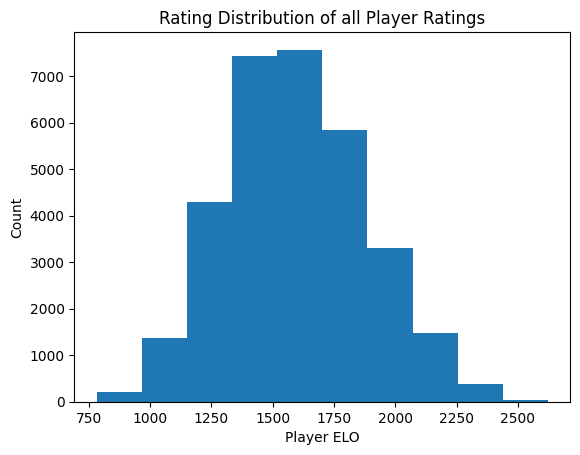

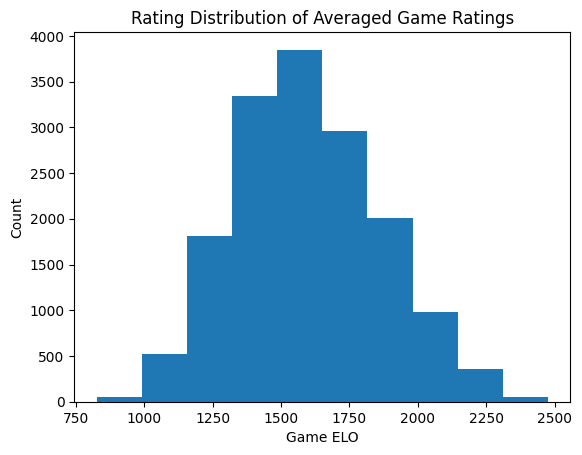

In [4]:
# Preliminary Data
print("Players of Black Ratings ---------------")
print("Mean:", chess_data["black_rating"].mean())
print("Median:", chess_data["black_rating"].median())
print()
print("Players of White Ratings ---------------")
print("Mean:", chess_data["white_rating"].mean())
print("Median:", chess_data["white_rating"].median())
print()
# Make array with every player (both black or white)
all_players = pd.concat([chess_data['white_rating'], chess_data['black_rating']], ignore_index=True)
print("All Player Ratings ---------------")
print("Mean:", all_players.mean())
print("Median:", all_players.median())
print()

# Visualization of rating distribution
plt.hist(all_players)
plt.title("Rating Distribution of all Player Ratings")
plt.xlabel("Player ELO")
plt.ylabel("Count")
plt.show()
plt.hist(chess_data['game_rating'])
plt.title("Rating Distribution of Averaged Game Ratings")
plt.xlabel("Game ELO")
plt.ylabel("Count")
plt.show()

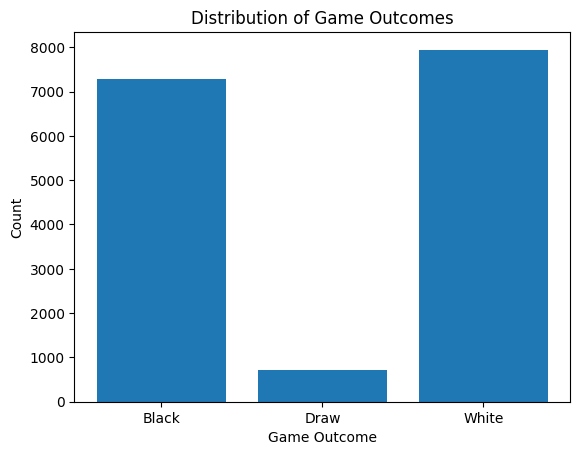

In [5]:
# Count occurrences of each outcome
counts = chess_data['winner'].value_counts().sort_index()

# Ensure order: Black (-1), Draw (0), White (1)
counts = counts.reindex([-1, 0, 1])

# Map labels
labels = ['Black', 'Draw', 'White']

# Plot
plt.figure()
plt.bar(labels, counts)
plt.title('Distribution of Game Outcomes')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

<Axes: ylabel='Count'>

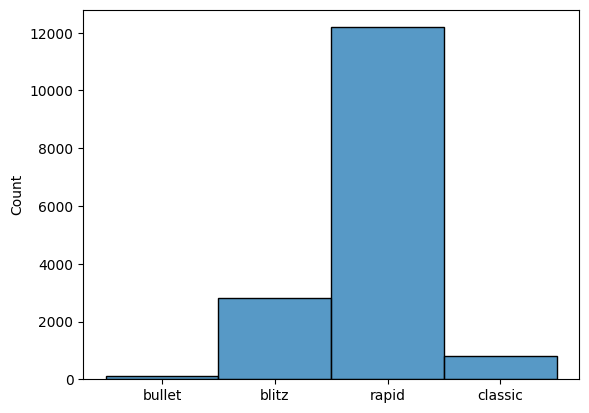

In [6]:
# Set Game Type
#Bullet – under 3 minutes
#Blitz – 3 to 8 minutes
#Rapid – 8 to 25 minutes
#Classical – 25+ minutes
chess_data['game_type'] = [int(_.split('+')[0]) for _ in chess_data['increment_code']]
type_map = {}
for i in range(0,chess_data['game_type'].max()+1):
    if i <= 3:
        type_map[i] = 0
    elif i <= 8:
        type_map[i] = 1
    elif i<= 25:
        type_map[i] = 2
    else:
        type_map[i] = 3
chess_data['game_type'] = chess_data['game_type'].map(type_map)
sns.histplot(pd.Categorical(chess_data['game_type'].map({0:'bullet',1:'blitz',2:'rapid',3:'classic'}),categories=['bullet','blitz','rapid','classic'],ordered=True))

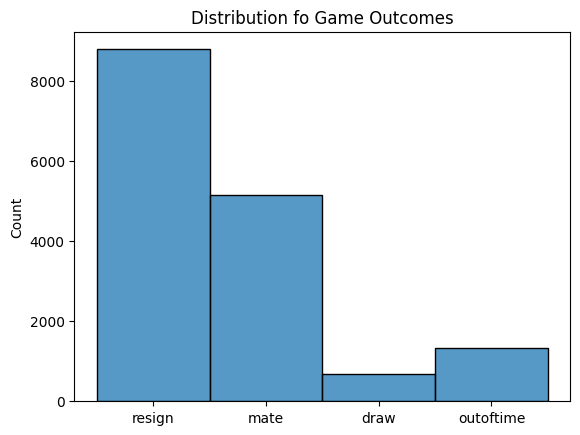

In [7]:
# Game outcome distribution
sns.histplot(pd.Categorical(chess_data['victory_status'].map({0:'resign',1:'mate',2:'draw',3:'outoftime'}),categories=['resign','mate','draw','outoftime'],ordered=True))
plt.title('Distribution fo Game Outcomes')
plt.show()

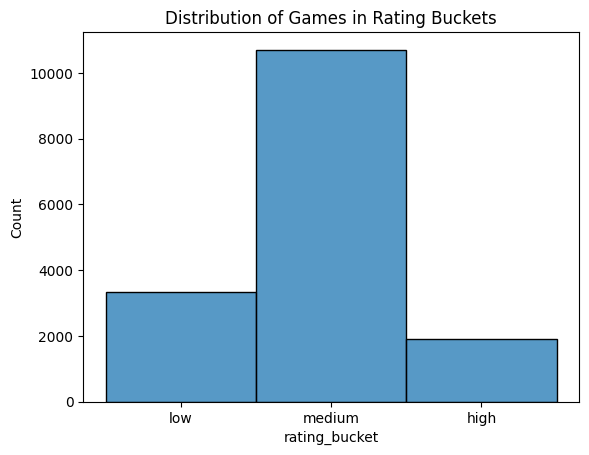

In [8]:
sns.histplot(chess_data['rating_bucket'])
plt.title('Distribution of Games in Rating Buckets')
plt.show()

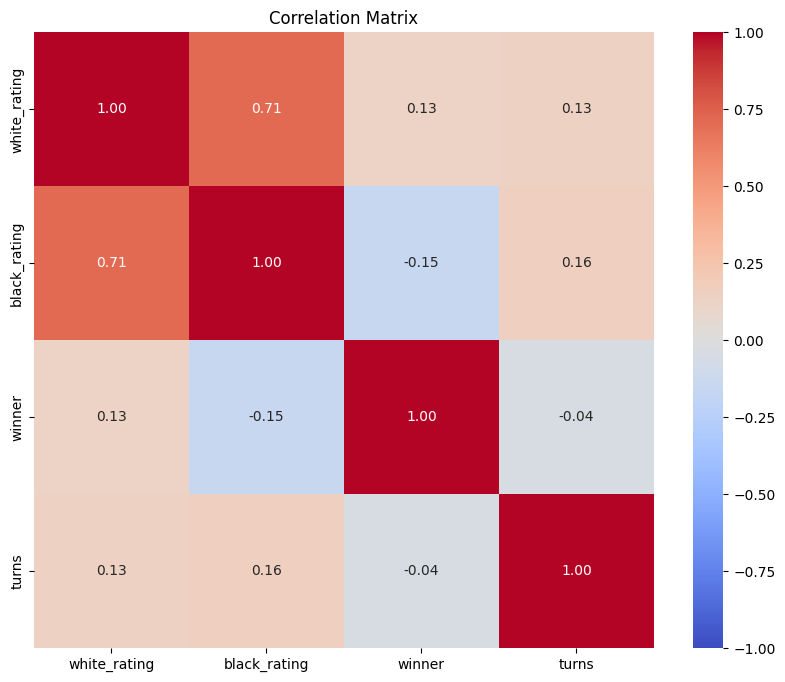

In [9]:
# Preliminary correlation matrix
chess_corr_data = chess_data[["white_rating", "black_rating", "winner", "turns"]]

corr_matrix = chess_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation Matrix")
plt.show()

#### 6.2. Chess Opening Analysis

This sections provides an analysis on possibly the most well-documented part of the game of chess: the openings. ELO blocks were used to separate opening analyses by rating.

##### Methods

Opening ecos were studied for each ELO group. Data acquired on each opening at each rating include: mean black/white rating, standard deviation of black/white rating, game winner, and amount of times opening was played. Data was visualized in histograms and scatterplots.

##### Results

The average amount of turns per game was centered at ~60. Player ELO did not appear to have significant impact on game length. The most popular openings over all players was found to be A00, C00, and D00. This popularity varied slightly by ELO category. At lower ELOs, the most popular openings were A00, C20, and B01. At medium ELOs, the most popular openings were C00, A00, and C41. At higher ELOs, the most popular openings were B01, C00, and D02. This difference is minimal, but may suggest patterns in what openings are most effective at certain ratings, whether by efficacy or by complexity. Further analysis is required.


In [10]:
# Get most popular opening for each rating block
def getOpeningPopularity(block,n):
      if block == "all":
            sample = chess_data
      else:
            sample = chess_data[chess_data["rating_bucket"]==block]
      # Get stats of opening
      eco_stats = sample.groupby("opening_eco").agg(
            white_rating_mean=("white_rating", "mean"),
            white_rating_std=("white_rating", "std"),
            black_rating_mean=("black_rating", "mean"),
            black_rating_std=("black_rating", "std"),
            count=("opening_eco", "size"),
            winner=("winner", "mean"),
      )
      most_popular = eco_stats.nlargest(n, "count")
      least_popular = eco_stats[eco_stats["count"] == 1]
      print("\n==========\n"
            f"Most Popular Opening for {block.capitalize()} Rating (ELO {sample["game_rating"].min()} - {sample["game_rating"].max()}):")
      print(most_popular)

# Run for all players and then by ELO group
getOpeningPopularity("all",10)
getOpeningPopularity("low",3)
getOpeningPopularity("medium",3)
getOpeningPopularity("high",3)


Most Popular Opening for All Rating (ELO 827.0 - 2475.5):
             white_rating_mean  white_rating_std  black_rating_mean  \
opening_eco                                                           
A00                1438.917001        270.184355        1503.564926   
C00                1569.739191        260.451977        1551.754533   
D00                1535.726334        276.846937        1551.266781   
B01                1537.666078        286.364382        1532.837456   
C41                1533.804618        240.503144        1494.978686   
C20                1393.653021        199.778433        1407.972710   
A40                1594.873984        291.793123        1551.583333   
B20                1542.671772        260.979375        1609.647702   
B00                1538.377528        273.609213        1477.939326   
C50                1560.594406        250.152614        1553.025641   

             black_rating_std  count    winner  
opening_eco                            

Average number of turns
62.7567584519852


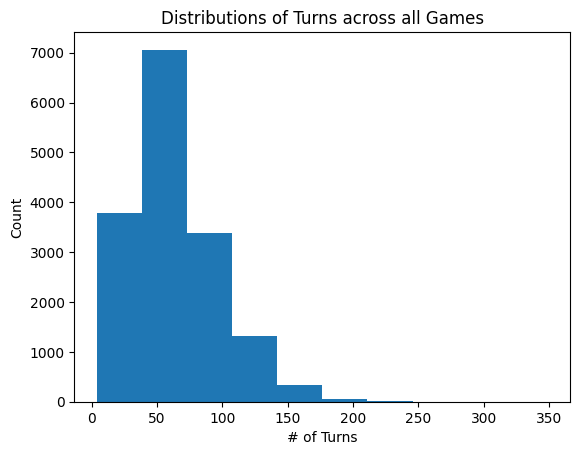

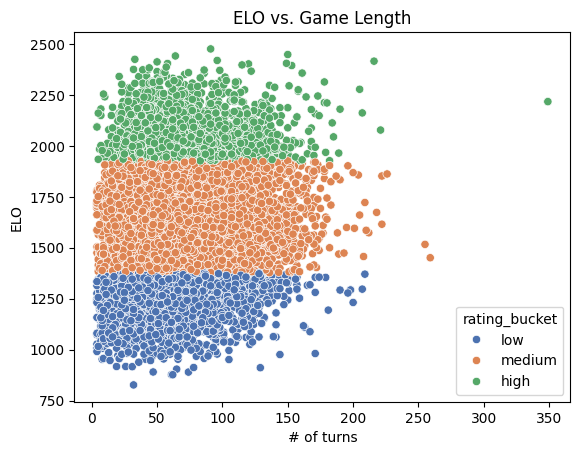

In [11]:
print("Average number of turns")
print(chess_data['turns'].mean())

# Turns visualization overall
plt.hist(chess_data['turns'])
plt.title("Distributions of Turns across all Games")
plt.xlabel("# of Turns")
plt.ylabel("Count")
plt.show()

# Turns by ELO
sns.scatterplot(x=chess_data["turns"], y=chess_data["game_rating"], hue=chess_data["rating_bucket"], palette="deep")
plt.title("ELO vs. Game Length")
plt.xlabel("# of turns")
plt.ylabel("ELO")
plt.show()

#### 6.3. Chess Board Analysis

The goal of this chess board analysis was to draw conclusions about chess strategy and generally how the game is played at different skill levels. The figures and stats generated below give interesting insights into this research goal.

##### Methods

The main analysis done for this milestone was piece movement analysis. Heatmaps were generated from this movement data. These heatmaps were created by making moves on a virtual chess board through python-chess (an open source python chess library). Each time a piece was moved to a square, that square received +1 moves. This was visually displayed as a heatmap that clearly shows trends. These heatmaps were split up into opening (the first few moves of the game), mid-game, and end-game (starts around move 30 and goes until the end). The goal was to provide a clear sense of how pieces tended to move at each stage of the game.

The results showed that the middle squares were always hotly contested, which made another question pop up: "Does taking control of the middle result in higher win rates?". This was studied by counting the number of center moves made by each player (black and white) and comparing that to victory data.

##### Results

The results show that throughout the game, the center squares are always hotly contested. I.e. they get moved to a lot. This happens at all skill levels (high-low ELO). This result is to be expected. One of the main strategies in chess is to control the center of the board. The results shows that when players move to the center of the board more often, they are (on average) slightly more likely to win. This is seen in the positive correlation between number of center moves and win outcome (correlation of 0.16).

Another intresting observation is that the beginning of the game is heavily focused on taking control of the center (and each diagonal square to the center). But after this, the midgame diffuses outward. As pieces develop (such as a bishop or the queen coming out), different squares get more contested. The is amplified in the end-game when the center is still of high importance, but all the other squares still receive a lot of action. Throughout all games, it is clear that the corners of the board are not particularly interesting squares. They do not see a lot of action. This might suggest that it is usually disadvantageous to be on the corners.

Overall, these preliminary results suggest that the center of the chess board is indeed very important. This large dataset provided clear evidence that controling the center is not only the standard strategy, but that it tends to work.

##### Code and Figures


13532


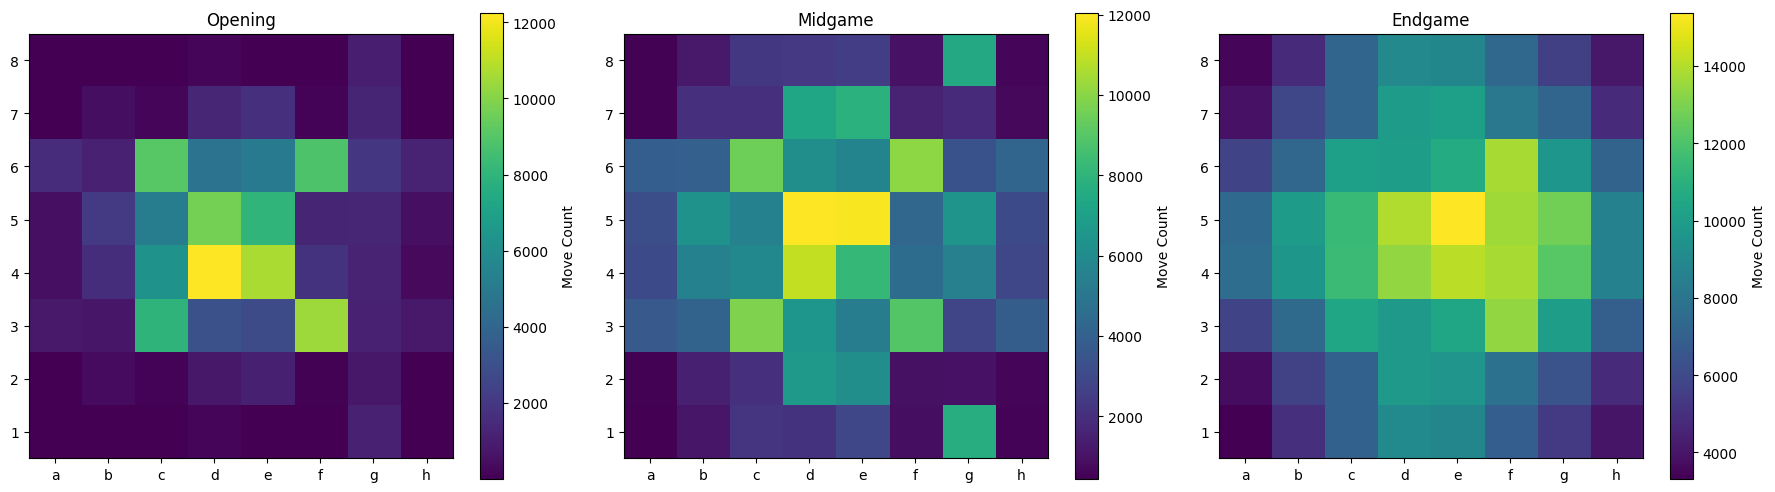

In [12]:
# Chess board heatmap. This function adds to a heatmap given a moveset and board.
def iterate_heatmap_from_moves(moves, board, heatmap):
    for san in moves:
        try:
            move = board.parse_san(san)
        except:
            break  # skip invalid games
        
        square = move.to_square
        
        # Convert square index → row, col
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        
        heatmap[row, col] += 1

        board.push(move)

# Grab games that are long enough to analyze
board_chess_games = chess_data[chess_data["turns"] > 30]
print(len(board_chess_games))

# 8x8 board (rank 8 at top, rank 1 at bottom)
opening_heatmap = np.zeros((8, 8))
mid_game_heatmap = np.zeros((8, 8))
end_game_heatmap = np.zeros((8, 8))

# Count moves for each square
for moves in board_chess_games["moves"]:
    board = chess.Board()

    opening = moves[:10]
    mid_game = moves[10:30]
    end_game = moves[30:]

    iterate_heatmap_from_moves(opening, board, opening_heatmap)
    iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
    iterate_heatmap_from_moves(end_game, board, end_game_heatmap)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmaps = [opening_heatmap, mid_game_heatmap, end_game_heatmap]
titles = ["Opening", "Midgame", "Endgame"]

for ax, data, title in zip(axes, heatmaps, titles):
    im = ax.imshow(data)  # no shared vmin/vmax → independent scaling
    
    ax.set_xticks(range(8))
    ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
    
    ax.set_yticks(range(8))
    ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
    
    ax.set_title(title)
    
    # Individual colorbar per subplot
    plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

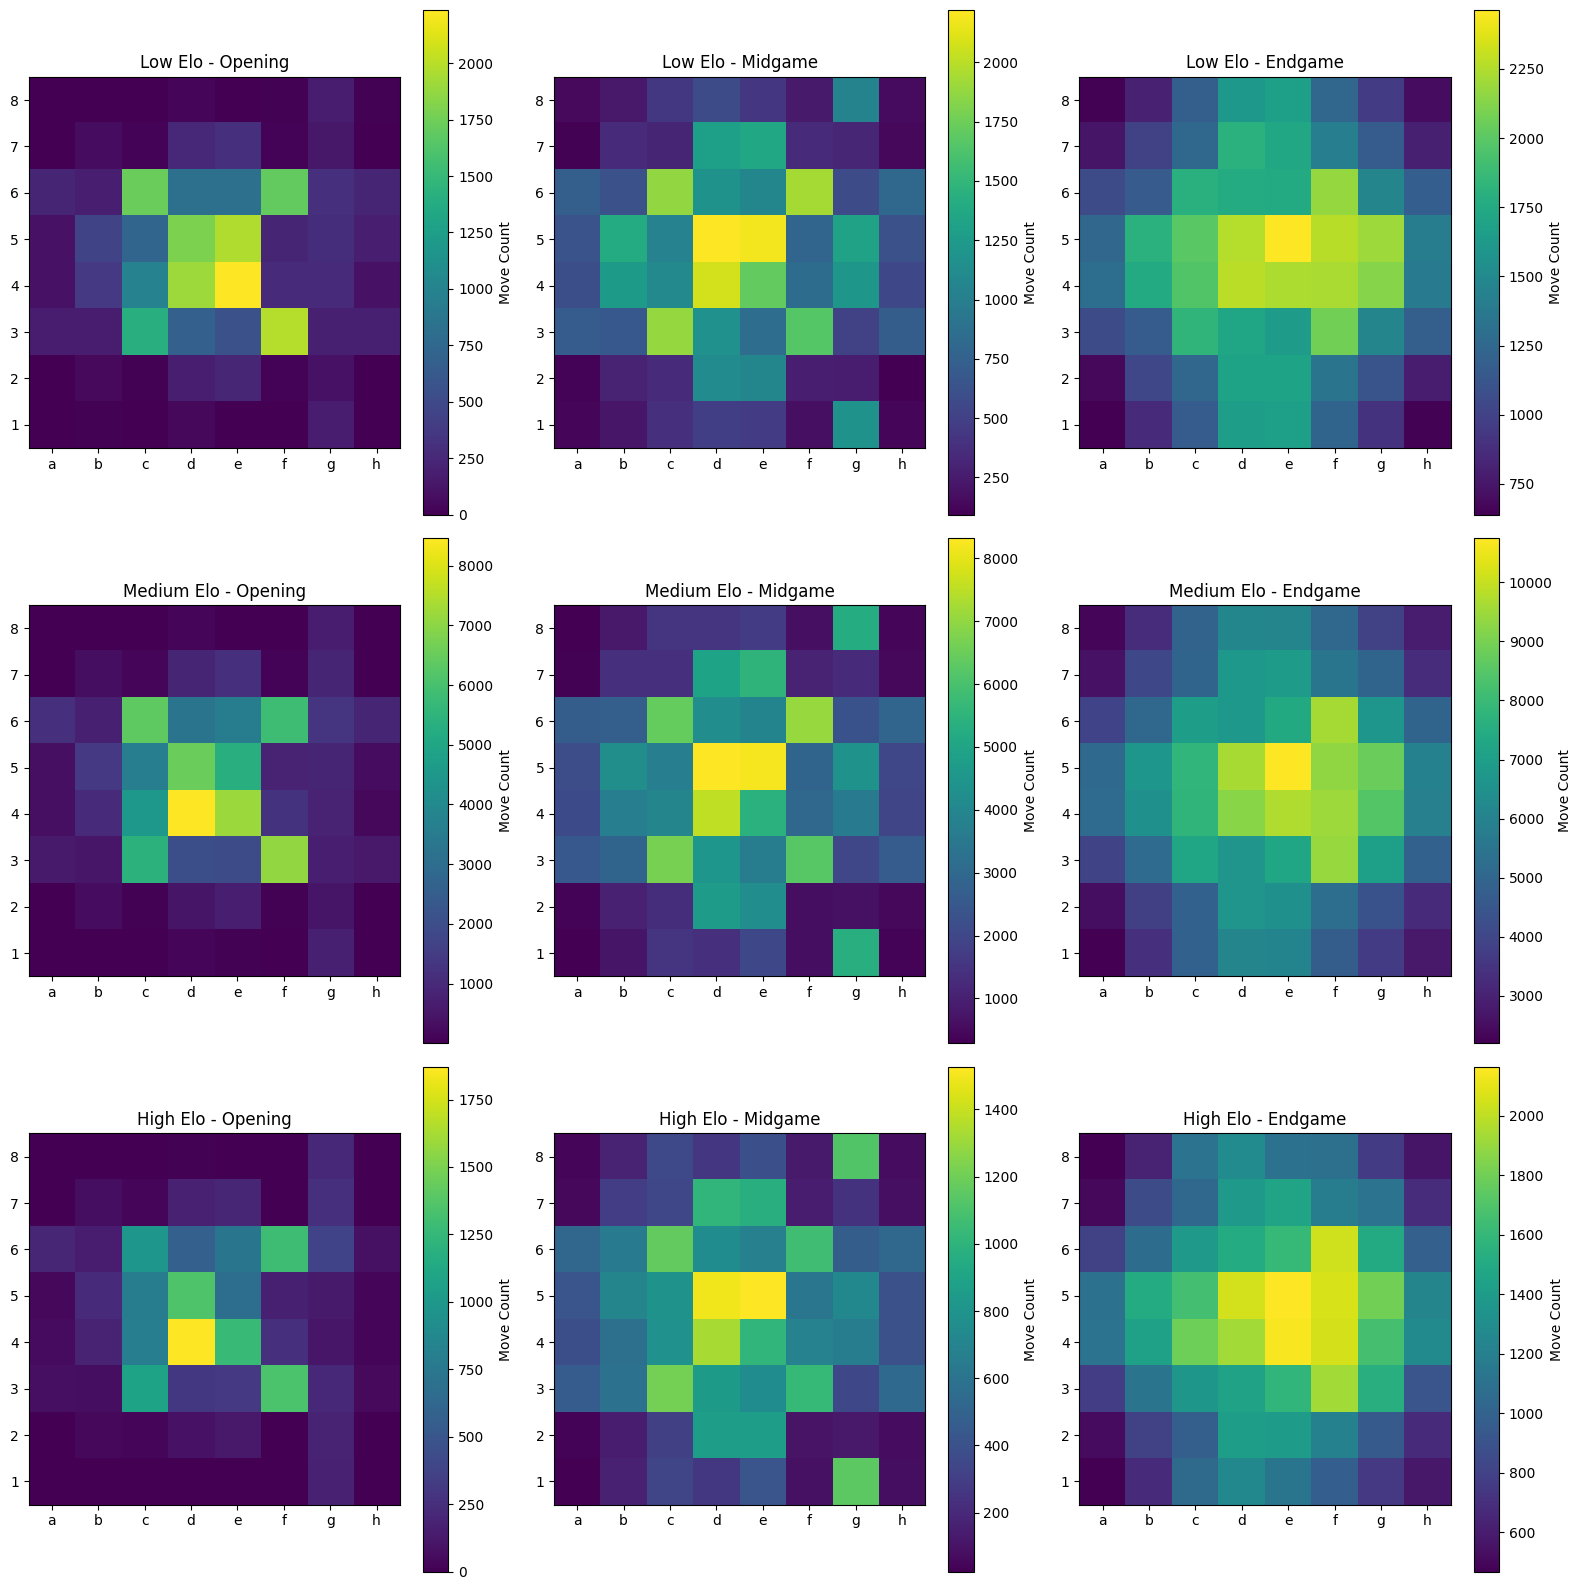

In [13]:
# This block plots a 3x3 grid displaying heatmaps of moves for gamestages and ELO ratings
# Elo buckets and game phases
buckets = ["low", "medium", "high"]
phases = ["Opening", "Midgame", "Endgame"]

# Store heatmaps for each bucket
all_heatmaps = {}

for bucket in buckets:
    opening_heatmap = np.zeros((8, 8))
    mid_game_heatmap = np.zeros((8, 8))
    end_game_heatmap = np.zeros((8, 8))
    
    bucket_games = board_chess_games[board_chess_games["rating_bucket"] == bucket]
    
    for moves in bucket_games["moves"]:
        board = chess.Board()

        opening = moves[:10]
        mid_game = moves[10:30]
        end_game = moves[30:]

        iterate_heatmap_from_moves(opening, board, opening_heatmap)
        iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
        iterate_heatmap_from_moves(end_game, board, end_game_heatmap)
    
    all_heatmaps[bucket] = [opening_heatmap, mid_game_heatmap, end_game_heatmap]

# Plot 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(16, 16))

for row, bucket in enumerate(buckets):
    for col, phase in enumerate(phases):
        ax = axes[row, col]
        data = all_heatmaps[bucket][col]
        
        im = ax.imshow(data)
        
        ax.set_xticks(range(8))
        ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
        ax.set_yticks(range(8))
        ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
        
        ax.set_title(f"{bucket.capitalize()} Elo - {phase}")
        
        plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

In [14]:
# This code block outputs the most contested and least contested squares for each ELO and phase of the game
# Convert to board label
def idx_to_square(row, col):
    file = ['a','b','c','d','e','f','g','h'][col]
    rank = ['8','7','6','5','4','3','2','1'][row]
    return f"{file}{rank}"

# Describe board status at each game state for each ELO group
for bucket in ["low", "medium", "high"]:
    print(f"\n=== {bucket.upper()} ELO ===")
    
    heatmaps = all_heatmaps[bucket]
    phase_names = ["Opening", "Midgame", "Endgame"]
    
    for phase_name, heatmap in zip(phase_names, heatmaps):
        
        # Most contested
        max_idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        max_square = idx_to_square(*max_idx)
        max_value = heatmap[max_idx]
        
        # Least contested
        min_idx = np.unravel_index(np.argmin(heatmap), heatmap.shape)
        min_square = idx_to_square(*min_idx)
        min_value = heatmap[min_idx]
        
        print(f"\n{phase_name}:")
        print(f"  Most contested: {max_square} ({max_value})")
        print(f"  Least contested: {min_square} ({min_value})")


=== LOW ELO ===

Opening:
  Most contested: e4 (2235.0)
  Least contested: a8 (0.0)

Midgame:
  Most contested: d5 (2221.0)
  Least contested: h2 (92.0)

Endgame:
  Most contested: e5 (2463.0)
  Least contested: a1 (638.0)

=== MEDIUM ELO ===

Opening:
  Most contested: d4 (8457.0)
  Least contested: a8 (1.0)

Midgame:
  Most contested: d5 (8319.0)
  Least contested: a1 (288.0)

Endgame:
  Most contested: e5 (10741.0)
  Least contested: a1 (2202.0)

=== HIGH ELO ===

Opening:
  Most contested: d4 (1872.0)
  Least contested: a8 (0.0)

Midgame:
  Most contested: e5 (1527.0)
  Least contested: a1 (25.0)

Endgame:
  Most contested: e5 (2164.0)
  Least contested: a8 (469.0)


In [15]:
# Center 16 Squares
# center_squares = {
#     chess.C3, chess.D3, chess.E3, chess.F3,
#     chess.C4, chess.D4, chess.E4, chess.F4,
#     chess.C5, chess.D5, chess.E5, chess.F5,
#     chess.C6, chess.D6, chess.E6, chess.F6
# }

# This code finds the number of center square moves for each player
# Center 4 Squares
center_squares = {
    chess.D4, chess.E4,
    chess.D5, chess.E5
}

def count_center_moves(moves):
    board = chess.Board()
    
    white_count = 0
    black_count = 0
    
    for move in moves:
        move_obj = board.parse_san(move)  # assumes SAN format like "e4", "Nf3"
        
        # Check destination square
        if move_obj.to_square in center_squares:
            if board.turn == chess.WHITE:
                white_count += 1
            else:
                black_count += 1
        
        board.push(move_obj)
    
    return white_count, black_count

# Apply row-wise and expand into two columns
board_chess_games[["white_center_moves", "black_center_moves"]] = (
    board_chess_games["moves"]
    .apply(lambda moves: pd.Series(count_center_moves(moves)))
)

/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_35928/414625595.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  board_chess_games[["white_center_moves", "black_center_moves"]] = (
/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_35928/414625595.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  board_chess_games[["white_center_moves", "black_center_moves"]] = (


In [16]:
# Describe center moves

# Finding the center move difference allows us to find correlation
# - A pos (+) value means white made more center moves
# - A neg (-) value means black made more center moves
board_chess_games["center_move_difference"] = board_chess_games["white_center_moves"] - board_chess_games["black_center_moves"]
print(board_chess_games.groupby("rating_bucket")["white_center_moves"].mean())
print(board_chess_games.groupby("rating_bucket")["black_center_moves"].mean())
print(board_chess_games["black_center_moves"].mean())

# Find the correlation between center moves and winner
board_chess_games["center_move_difference"].corr(board_chess_games["winner"])

rating_bucket
low       5.161354
medium    5.461655
high      5.698740
Name: white_center_moves, dtype: float64
rating_bucket
low       4.808737
medium    4.955111
high      5.083047
Name: black_center_moves, dtype: float64
4.944132426840083


/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_35928/4223096603.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  board_chess_games["center_move_difference"] = board_chess_games["white_center_moves"] - board_chess_games["black_center_moves"]
/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_35928/4223096603.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(board_chess_games.groupby("rating_bucket")["white_center_moves"].mean())
/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_35928/4223096603.py:8: FutureWarning: The 

np.float64(0.1657928063977587)

#### 6.4. Piece Analysis

Pieces were analyzed to try to figure out which pieces are of high importance. Chess has a standardized point system for rating pieces, is this system accurate? This section also explores whether differences in player ELO affects which pieces tend to be used.

##### Methods

Game movement data was analyzed using a virtual python-chess board. Moves were made on this board (from the dataset) and if a move was made by a piece, it was added to that game's total. Graphs of these results were generated.

##### Results

The results show that pawns are moved the most out of any piece. This makes sense. Pawns are the most abundant and expendable piece. They are also key in all phases of the game. You use them to take control of the center in the opening, you advanced them to strike enemy weeknesses in the mid-game, and try to get them to the back rank for promotion in the end-game. A suprising result was how little queens were moved. Queens are the most powerful piece and biggest threat to the oponnent. However, they were the second least moved piece (behind the king). This is most likely because there is only one queen. There are multiples of all other pieces, so they will logically be moved more. Breaking the moves down by ELO demonstrated that high level chess does not change the types of pieces you use more often. There was a lot of uniformity in the pieces used between the three levels of ELO. The largest difference was between rook usage. It seems that high level players tend to move the rook more often.

These preliminary results demonstrate the importance of pawns. They were moved the most by every skill level. Additionally, the results demonstrated that higher level players tend to use the rook more often than lower ELO players. This demonstrates that the rook is perhaps a harder piece to master.

##### Code and Figures


In [17]:
# Get copy of dataframe to play with
piece_chess_data = chess_data.copy()

# Count the number of times each piece was moved per game
def count_piece_moves(moves):
    board = chess.Board()

    counts = {
        "white_pawn_moves": 0,
        "white_knight_moves": 0,
        "white_bishop_moves": 0,
        "white_rook_moves": 0,
        "white_queen_moves": 0,
        "white_king_moves": 0,
        "black_pawn_moves": 0,
        "black_knight_moves": 0,
        "black_bishop_moves": 0,
        "black_rook_moves": 0,
        "black_queen_moves": 0,
        "black_king_moves": 0,
    }

    piece_name = {
        chess.PAWN: "pawn",
        chess.KNIGHT: "knight",
        chess.BISHOP: "bishop",
        chess.ROOK: "rook",
        chess.QUEEN: "queen",
        chess.KING: "king",
    }

    # Pass moves into virtual chess board
    for move in moves:
        move_obj = board.parse_san(move)

        moving_piece = board.piece_at(move_obj.from_square)
        if moving_piece is None:
            board.push(move_obj)
            continue

        color = "white" if moving_piece.color == chess.WHITE else "black"
        piece = piece_name[moving_piece.piece_type]

        counts[f"{color}_{piece}_moves"] += 1

        board.push(move_obj)

    return pd.Series(counts)

In [18]:
piece_move_counts = piece_chess_data["moves"].apply(count_piece_moves)
piece_chess_data = pd.concat([piece_chess_data, piece_move_counts], axis=1)

In [19]:
# Summary of moves
combined = {
    "pawn": piece_chess_data["white_pawn_moves"].sum() + piece_chess_data["black_pawn_moves"].sum(),
    "knight": piece_chess_data["white_knight_moves"].sum() + piece_chess_data["black_knight_moves"].sum(),
    "bishop": piece_chess_data["white_bishop_moves"].sum() + piece_chess_data["black_bishop_moves"].sum(),
    "rook": piece_chess_data["white_rook_moves"].sum() + piece_chess_data["black_rook_moves"].sum(),
    "queen": piece_chess_data["white_queen_moves"].sum() + piece_chess_data["black_queen_moves"].sum(),
    "king": piece_chess_data["white_king_moves"].sum() + piece_chess_data["black_king_moves"].sum(),
}

combined_series = pd.Series(combined).sort_values(ascending=False)
print(combined_series)

pawn      275340
knight    175196
bishop    154239
rook      138541
king      131836
queen     125379
dtype: int64


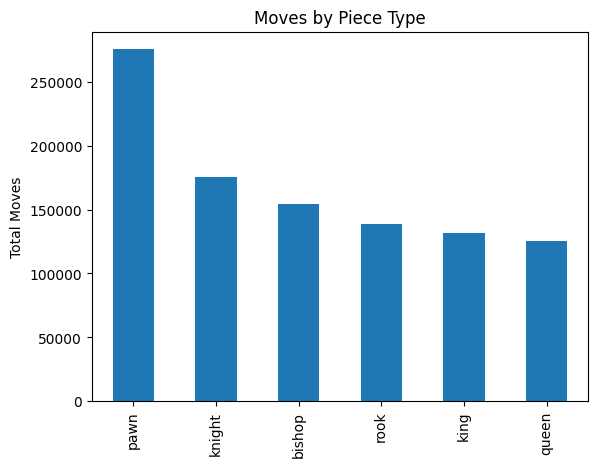

In [20]:
# Plot moves by every piece
combined_series.plot(kind="bar")
plt.ylabel("Total Moves")
plt.title("Moves by Piece Type")
plt.show()

/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_35928/2953767315.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_df.groupby(piece_chess_data["rating_bucket"]).sum()


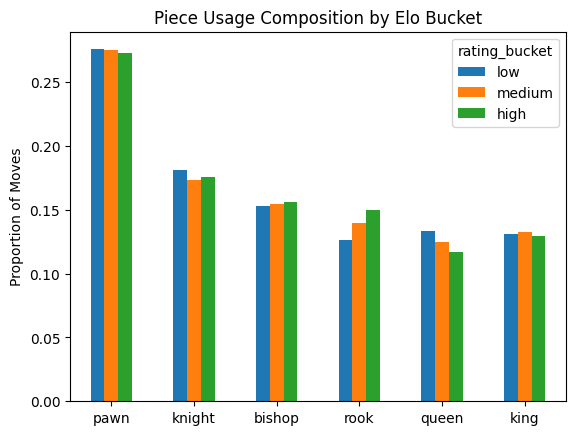

In [21]:
# Plot moves by ELO and pieces
combined_df = pd.DataFrame({
    "pawn": piece_chess_data["white_pawn_moves"] + piece_chess_data["black_pawn_moves"],
    "knight": piece_chess_data["white_knight_moves"] + piece_chess_data["black_knight_moves"],
    "bishop": piece_chess_data["white_bishop_moves"] + piece_chess_data["black_bishop_moves"],
    "rook": piece_chess_data["white_rook_moves"] + piece_chess_data["black_rook_moves"],
    "queen": piece_chess_data["white_queen_moves"] + piece_chess_data["black_queen_moves"],
    "king": piece_chess_data["white_king_moves"] + piece_chess_data["black_king_moves"],
})

grouped = combined_df.groupby(piece_chess_data["rating_bucket"]).sum()
normalized = grouped.div(grouped.sum(axis=1), axis=0)
plot_data = normalized.T
plot_data.plot(kind="bar")

plt.ylabel("Proportion of Moves")
plt.title("Piece Usage Composition by Elo Bucket")
plt.xticks(rotation=0)
plt.show()

## 7. Data Processing/Analysis Methodology


#### 7.1. Board Chess Engine

The following data processing was done because the raw move data provided by the data source is unusable. A virtual chess board must be used to analyze positions (snapshots of the chess game). The data processing pipeline is as follows: raw movement data -> analyzed by virtual chess board -> gather statistics -> create new dataframe with all statistics.

The data to be gathered from this virtual chess board is focused on chess tactics and strategies. The goal is to extract how each player (black and white) played the game. It finds checks, captures, forks, pins, attacks, and defenses (all common chess strategies) for every piece and each color. Knowing this could provide important details about the game that can be used later on in analysis and prediction.


In [22]:
# -------------------------------------------------------
# Use Python Chess to get parameters for neural net
# -------------------------------------------------------


def board_analysis(movelist):
    piece_lookup = {
        chess.PAWN: "pawn",
        chess.KNIGHT: "knight",
        chess.BISHOP: "bishop",
        chess.ROOK: "rook",
        chess.QUEEN: "queen",
        chess.KING: "king",
    }
    piece_values = {
        chess.PAWN: 1,
        chess.KNIGHT: 3,
        chess.BISHOP: 3,
        chess.ROOK: 5,
        chess.QUEEN: 9,
        chess.KING: 0,
    }
    colors = ["white", "black"]
    categories = [
        "moves",
        "captures",
        "checks",
        "forks",
        "pins",
        "attacks",
        "defenses",
        "center_control_turns",
    ]
    pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
    center_squares = [chess.D4, chess.E4, chess.D5, chess.E5]

    analysis = {
        color: {
            category: {piece: 0 for piece in pieces}
            for category in categories
        }
        for color in colors
    }
    promotion_counts = {color: 0 for color in colors}
    forced_move_counts = {color: 0 for color in colors}
    material_taken = {color: 0 for color in colors}
    material_lost = {color: 0 for color in colors}

    board = chess.Board()

    for san in movelist:
        try:
            move = board.parse_san(san)
        except Exception:
            break

        color = "white" if board.turn == chess.WHITE else "black"
        opponent_color = "black" if color == "white" else "white"
        piece = board.piece_at(move.from_square)

        if piece is None:
            break

        piece_name = piece_lookup[piece.piece_type]
        analysis[color]["moves"][piece_name] += 1

        captured_value = 0
        if board.is_capture(move):
            analysis[color]["captures"][piece_name] += 1
            if board.is_en_passant(move):
                captured_value = piece_values[chess.PAWN]
            else:
                captured_piece = board.piece_at(move.to_square)
                if captured_piece is not None:
                    captured_value = piece_values[captured_piece.piece_type]

        material_taken[color] += captured_value
        material_lost[opponent_color] += captured_value

        board.push(move)

        if board.is_check():
            analysis[color]["checks"][piece_name] += 1

        attacked_enemy_pieces = 0
        defended_friendly_pieces = 0
        pinned_enemy_pieces = 0
        for square in board.attacks(move.to_square):
            target_piece = board.piece_at(square)
            if target_piece is None:
                continue
            if target_piece.color != piece.color:
                attacked_enemy_pieces += 1
                if board.is_pinned(target_piece.color, square):
                    pinned_enemy_pieces += 1
            else:
                defended_friendly_pieces += 1

        analysis[color]["attacks"][piece_name] += attacked_enemy_pieces
        analysis[color]["defenses"][piece_name] += defended_friendly_pieces

        if attacked_enemy_pieces >= 2:
            analysis[color]["forks"][piece_name] += 1

        if pinned_enemy_pieces > 0:
            analysis[color]["pins"][piece_name] += pinned_enemy_pieces

        if move.promotion is not None:
            promotion_counts[color] += 1

        if board.legal_moves.count() == 1:
            forced_move_counts[color] += 1

        for square in center_squares:
            center_piece = board.piece_at(square)
            if center_piece is None:
                continue
            center_color = "white" if center_piece.color == chess.WHITE else "black"
            center_piece_name = piece_lookup[center_piece.piece_type]
            analysis[center_color]["center_control_turns"][center_piece_name] += 1

    flattened_vector = []
    for color in colors:
        for category in categories:
            for piece in pieces:
                flattened_vector.append(analysis[color][category][piece])

    for color in colors:
        flattened_vector.extend([
            promotion_counts[color],
            forced_move_counts[color],
            material_taken[color],
            material_lost[color],
        ])

    return flattened_vector


In [23]:
colors = ["white", "black"]
categories = [
    "moves",
    "captures",
    "checks",
    "forks",
    "pins",
    "attacks",
    "defenses",
    "center_control_turns",
]
pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
summary_metrics = ["promotions", "forced_moves", "material_taken", "material_lost"]

neural_net_columns = [
    f"{color}_{category}_{piece}"
    for color in colors
    for category in categories
    for piece in pieces
] + [
    f"{color}_{metric}"
    for color in colors
    for metric in summary_metrics
]

neural_net_columns += [
    "white_elo",
    "black_elo",
    "winner",
    "total_turns",
    "white_turns",
    "black_turns",
    "idx"
]

neural_net_rows = []

for idx, row in chess_data.iterrows():
    total_turns = row["turns"]
    white_turns = (total_turns + 1) // 2
    black_turns = total_turns // 2

    board_analysis_row = board_analysis(row["moves"])
    board_analysis_row += [
        row["white_rating"],
        row["black_rating"],
        row["winner"],
        total_turns,
        white_turns,
        black_turns,
        idx
    ]
    neural_net_rows.append(board_analysis_row)

board_analysis_results = pd.DataFrame(neural_net_rows, columns=neural_net_columns)
board_analysis_results = board_analysis_results.set_index('idx').sort_index()
board_analysis_results.describe()


,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,black_promotions,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,total_turns,white_turns,black_turns
count,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000,...,15943.000000,15943.000000,15943.000000,15943.000000,15943.00000,15943.000000,15943.000000,15943.000000,15943.000000,15943.000000
mean,8.607288,5.57831,4.966067,4.442828,4.010977,4.032052,1.841247,1.363984,1.430095,1.172803,...,0.080223,0.353008,20.199272,20.374020,1599.90949,1596.395660,0.041147,62.756758,31.637521,31.119237
std,4.381908,3.43769,3.048665,5.252713,3.749370,5.677335,1.375202,1.241930,1.195479,1.490381,...,0.314457,0.908748,11.310281,11.261918,282.71278,287.500823,0.976612,33.240935,16.615902,16.628786
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,784.00000,789.000000,-1.000000,4.000000,2.000000,2.000000
25%,5.000000,3.00000,3.000000,1.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,11.000000,11.000000,1399.00000,1393.000000,-1.000000,39.000000,20.000000,19.000000
50%,8.000000,5.00000,4.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,20.000000,20.000000,1579.00000,1576.000000,0.000000,57.000000,29.000000,28.000000
75%,11.000000,7.00000,6.000000,6.000000,5.000000,5.000000,3.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,29.000000,30.000000,1795.00000,1793.000000,1.000000,81.000000,41.000000,40.000000
max,35.000000,59.00000,44.000000,83.000000,41.000000,74.000000,8.000000,11.000000,11.000000,9.000000,...,5.000000,16.000000,55.000000,55.000000,2622.00000,2588.000000,1.000000,349.000000,175.000000,174.000000


In [24]:
board_analysis_results

,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,black_promotions,black_forced_moves,black_material_taken,black_material_lost,white_elo,black_elo,winner,total_turns,white_turns,black_turns
idx,,,,,,,,,,,,,,,,,,,,,
1,6,0,0,0,2,0,2,0,0,0,...,0,0,11,2,1322,1261,-1.0,16,8,8
2,12,3,8,5,3,0,7,1,3,3,...,0,0,7,38,1496,1500,1.0,61,31,30
3,4,9,4,3,10,1,1,3,2,0,...,0,0,8,30,1439,1454,1.0,61,31,30
4,13,8,3,16,4,4,1,3,1,5,...,0,1,30,38,1523,1469,1.0,95,48,47
6,3,4,5,0,4,1,0,2,0,0,...,0,0,9,9,1520,1423,1.0,33,17,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,3,4,3,1,0,1,0,1,1,0,...,0,0,4,2,1691,1220,1.0,24,12,12
20054,8,11,3,2,8,9,2,3,0,0,...,0,1,26,25,1233,1196,-1.0,82,41,41
20055,3,6,5,0,4,0,0,0,2,0,...,0,0,6,4,1219,1286,1.0,35,18,17


#### 7.2. Stockfish Analysis

The chess engine "Stockfish" was imported and used to gather centipawn loss data across all games in the dataset. Centipawn loss is a standardized chess metric used to describe the "accuracy" of any move. A positive value indicates a beneficial move for the player while a negative value indicates a mistake. The magnitude of this value then indicates how drastic the move was, ultimately spiking in value to representt checkmates. The Stockfish engine calculates this by intaking the list of moves made in a particular game. Then, it simulates the board, pieces, and moves sequentially by each move in the list. The centipawn loss is then estimated for each move using the culmination of these parameters and board states. This calculation can be limited by move depth (also factors in x future possible moves for each move) or by time (strict time limit for analysis of each move).

In practice, limiting by a move depth of 12 versus a time limit of 1ms showed similar enough centipawn ranges to rely on 1ms limits only for final data analysis. As another point of refrence, the depth limited analysis took 2-3 hours for the entire dataset whereas the time limited analysis took 15-60 minutes for the entire dataset. Thus, the time limited Stockfish analysis was run 5 times and averaged to determine average centipawn loss data for the full dataset.

The times listed for both forms of analysis are already truncated; if the engine were left to run straightforward through the dataset, it would take more than a day to complete one full analysis. That is why the most difficult part of the Stockfish analysis was speeding up the processing time. 4 CPU cores, each with 2 threads and 256 hash, were used for every round of analysis. The data was chunked into groups for each of these cores and the chunks were then pooled and evaluated to run the analyses in parallel. With this method, the speed of centipawn calculation for the entire dataset was minimized from more than one day to 1-3 hours. The time limited analysis that was run 5 times for final centipawn loss data was left to process overnight for only 4-5 hours.

Final centipawn loss values were exported to csv files after every full dataset iteration to prevent data loss. The final 5 runs were saved, compiled, averaged, and stored in the chess dataset for future data analysis. Centipawn loss data correlates directly to the moves made in every game: all even indexed values are from the perspective of white and all odd indexed values are from the perspective of black. Note that since the analyses is mapped solely to move data, not all games necessarily end in a centipawn loss spiking in magnitude. Resigns, out of times, and draws may not reflect the standard expected pattern of centipawn loss in games.


In [25]:
# Worker Function
STOCKFISH_PATH = "/opt/homebrew/bin/stockfish"
DEPTH = 12 
TIME = 0.001

def evaluate_moves(chunk):
    results = []

    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        engine.configure({"Threads": 2, "Hash": 256})

        for i, moves in chunk:
            board = chess.Board()
            centipawn = []

            for m in moves:
                info = engine.analyse(board, chess.engine.Limit(time=TIME))
                # Elements 0, 2, 4, ... are white perspective
                # Elements 1, 3, 5, ... are black perspective
                score = info["score"].relative

                if score.is_mate():
                    cp = 100000 if score.mate() > 0 else -100000
                else:
                    cp = score.score()

                centipawn.append(cp)
                board.push_san(m)

            results.append((i, centipawn))

    return results

# Chunking Function
def make_indexed_chunks(df, n_chunks):
    chunks = np.array_split(df, n_chunks)
    return [
        [(idx, row["moves"]) for idx, row in chunk.iterrows()]
        for chunk in chunks
    ]

In [26]:
n_workers = 4
chunks = make_indexed_chunks(chess_data, n_workers)
ctx = mp.get_context("spawn")

for run in range(5):
    continue
    results = Pool(2).map(evaluate_moves, chunks)

    out_data = pd.DataFrame(
        [item for chunk in results for item in chunk],
        columns=["index", "centipawn"]
    )

    out_data = out_data.set_index("index").sort_index()
    out_data.to_csv("centipawn_data_run_"+str(run)+".csv")
    print(str(run) +  " Complete")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [27]:
# Assign centipawn post-processing
cp = pd.DataFrame()
for r in range (5):
    cp_raw = pd.read_csv("centipawn/centipawn_data_run_"+str(r)+".csv")
    if r == 0: cp['index'] = cp_raw['index']
    cp[str(r)] = cp_raw['centipawn'].apply(lambda row: [int(value.strip()) for value in row.strip('[]').split(',')])
cp = cp.set_index('index').sort_index()
cp['average'] = cp[['0','1','2','3','4']].apply(lambda row: np.mean(np.array(row.tolist()),axis=0).astype(int),axis=1)
chess_data['centipawn'] = cp['average']
# Separate black/white
chess_data['centipawn_white'] = cp['average'].apply(lambda x: x[::2])
chess_data['centipawn_black'] = cp['average'].apply(lambda x: x[1::2])
chess_data['centipawn_white_avg'] = chess_data['centipawn_white'].apply(lambda row: np.mean(row))
chess_data['centipawn_black_avg'] = chess_data['centipawn_black'].apply(lambda row: np.mean(row))
chess_data['centipawn_avg'] = (chess_data['centipawn_white_avg'] + chess_data['centipawn_black_avg']) /2

In [28]:
# New Opening standardization
print(len(chess_data))
chess_data['opening_aggro'] = chess_data['opening_eco'].str[0].map({'A':4,'B':1,'C':3,'D':5,'E':2})
chess_data['opening_skill'] = chess_data['opening_eco'].str[0].map({'A':5,'B':1,'C':3,'D':4,'E':2})
chess_data['opening_diff'] = chess_data['opening_eco'].str[0].map({'A':2,'B':5,'C':3,'D':1,'E':4})

# Adding Board Analyses
new_results = board_analysis_results.drop(columns=['winner','total_turns','white_elo','black_elo'])
chess_data = pd.concat([chess_data, new_results], axis=1)
chess_data.head()


15943


,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,...,white_promotions,white_forced_moves,white_material_taken,white_material_lost,black_promotions,black_forced_moves,black_material_taken,black_material_lost,white_turns,black_turns
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,...,0,0,2,11,0,0,11,2,8,8
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,...,0,1,38,7,0,0,7,38,31,30
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,...,0,7,30,8,0,0,8,30,31,30
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,...,1,0,38,30,0,1,30,38,48,47
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,...,0,1,9,9,0,0,9,9,17,16


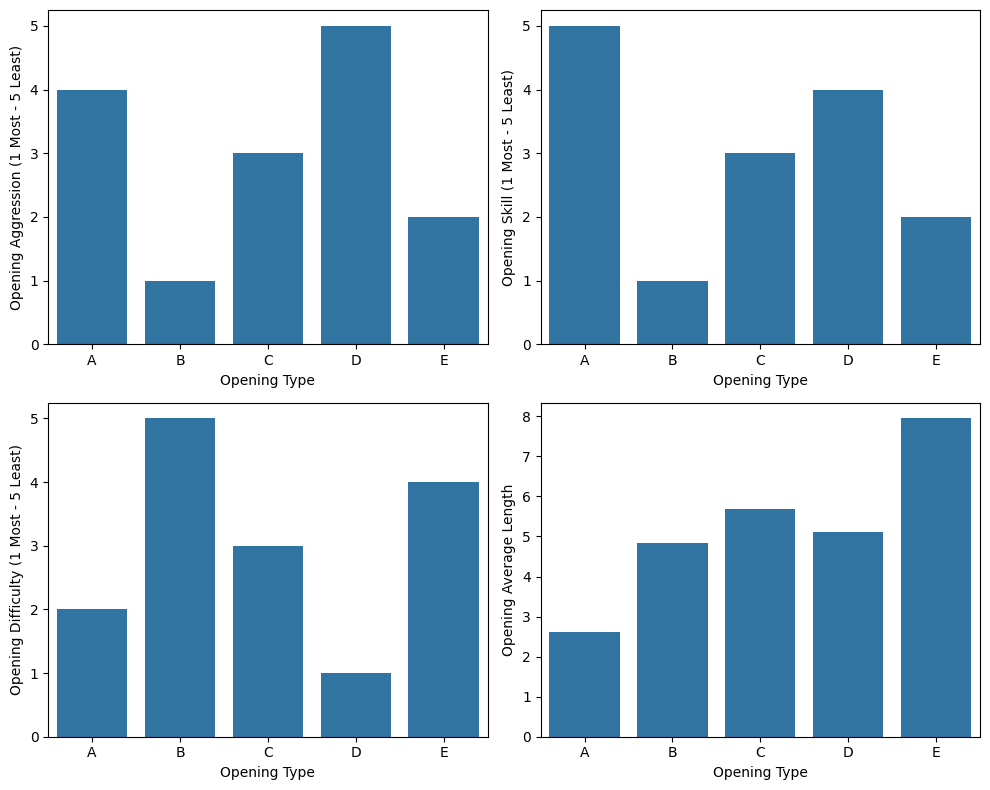

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_aggro'].mean(),ax=axes[0,0])
axes[0,0].set_xlabel('Opening Type')
axes[0,0].set_ylabel('Opening Aggression (1 Most - 5 Least)')
sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_skill'].mean(),ax=axes[0,1])
axes[0,1].set_xlabel('Opening Type')
axes[0,1].set_ylabel('Opening Skill (1 Most - 5 Least)')
sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_diff'].mean(),ax=axes[1,0])
axes[1,0].set_xlabel('Opening Type')
axes[1,0].set_ylabel('Opening Difficulty (1 Most - 5 Least)')
sns.barplot(data=chess_data.groupby(chess_data['opening_eco'].str[0])['opening_ply'].mean(),ax=axes[1,1])
axes[1,1].set_xlabel('Opening Type')
axes[1,1].set_ylabel('Opening Average Length')

plt.tight_layout()
plt.show()


Exploratory figure showing types of opening and their aggressivenes, skill, difficulty, and average length. Added to better classify openings for regression models.


## 8. Answering Question 1

### Can we utilize patterns in the data to differentiate between the gameplay style of experienced players vs inexperienced players?


/var/folders/ht/hl9jgtyx3r1fspmzcfk8j4d00000gn/T/ipykernel_35928/1689474211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(chess_data.groupby('rating_bucket')['centipawn_avg'].mean())


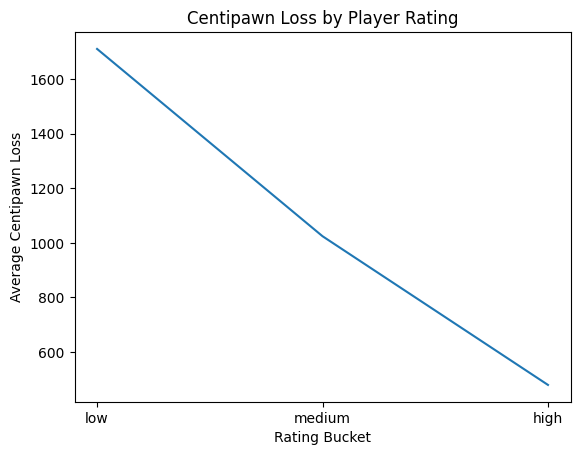

In [30]:
plt.plot(chess_data.groupby('rating_bucket')['centipawn_avg'].mean())
plt.title('Centipawn Loss by Player Rating')
plt.xlabel('Rating Bucket')
plt.ylabel('Average Centipawn Loss')
plt.show()

Aftetr running centipawn loss analysis on the list of moves in each game, the average centipawn loss of each game was taken. These values were then averaged according to the three rating brackets of low, medium, and high ELO players. The graph above reveals that the average centipawn loss of each game appears to drop as the player rating increases. This intuitively makes sense, as magnitudes of centipawn loss represent large successes or failures per move in a game. Lower level players may be more susceptible to making detrimental mistakes, whereas higher level players may be more aware of similar mistakes. This pertains even if the moves appear more risky, as a more thought-out strategy may require seemingly disastrous moves, making their actual centipawn loss less extreme.


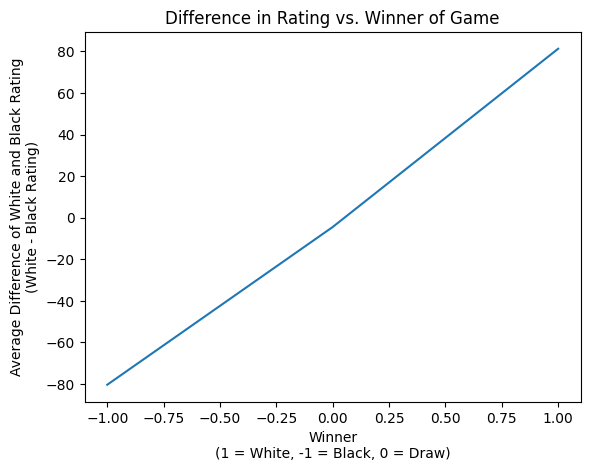

In [31]:
plt.plot((chess_data['white_rating'] - chess_data['black_rating']).groupby(chess_data['winner']).mean())
plt.title('Difference in Rating vs. Winner of Game')
plt.xlabel('Winner\n(1 = White, -1 = Black, 0 = Draw)')
plt.ylabel('Average Difference of White and Black Rating\n(White - Black Rating)')
plt.show()

The figure shown above demonstrates the average difference in rating between the white and black players of a game plotted against the winner of said game. This graph implies that, on average, the winners of a game are typically ~80 ELO higher than their opponents, whether that be white or black. And for games that end in draws, both players are more equivalent in their ratings. This finding makes logical sense, as the victor of a game would be assumed to be "better" than the opponent in some way. However, using averages only in this graph enforces limitations on the applicability for the full range of chess games in the dataset. Interpret graph with caution before making assumptions.


In [32]:
# Linear Regression Model
def linearModel(df,ins,outs):
    inputs = ''
    for i in ins:
        inputs += i + ' + '
    inputs = inputs[0:len(inputs)-3]
    model = sm.ols(formula=f"{outs} ~ {inputs}", data=df).fit()
    mse = mean_squared_error(df[outs], model.predict(df))
    print(f'Linear model predicting: {outs}')
    print(f'MSE: {mse}')
    print(f'R^2: {model.rsquared}')
    #display(model.summary())

# Ridge or Lasso Regression Model
def runModel(df,ins,outs,m):
    train_set,test_set = train_test_split(df, test_size=0.2, random_state=1)
    x_train = StandardScaler().fit_transform(train_set[ins])
    x_test = StandardScaler().fit_transform(test_set[ins])
    y_train = train_set[outs]
    y_test = test_set[outs]
    lam = np.logspace(-10,5,20)
    mse = []
    for a in lam:
        if m == 'ridge':
            model = Ridge(alpha=a).fit(x_train,y_train)
            mse.append(mean_squared_error(y_test, model.predict(x_test)))
        if m == 'lasso':
            model = Lasso(alpha=a).fit(x_train,y_train)
            mse.append(mean_squared_error(y_test, model.predict(x_test)))

    print(f'Optimal Lamda Value: {lam[mse.index(min(mse))]}')
    plt.plot(lam,mse)
    plt.title(f'{m} regression model predicting {outs}')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.xlabel('Lambda Value')
    plt.show()

In [33]:
ins = list(chess_data.iloc[:, 19:].columns)
ins.append('turns')
ins.append('game_rating')
outs = 'centipawn_avg'
linearModel(chess_data,ins,outs)

Linear model predicting: centipawn_avg
MSE: 2843537.3712902586
R^2: 0.16805731760583542


By compiling board analyses data, opening data, player ratings, and game length, the linear regression model was not able to accurately predict the average centipawn loss value of a game of chess. The R^2 value is too low and the MSE is critically high. This finding shows that centipawn loss may not be directly linearly correlated with the player ratings or what specific strategies they use. Instead, a deeper connection between the parameters may exist that cannot be fully encapsulated by simple linear regression.


Optimal Lamda Value: 428.13323987193957


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.118665664730183e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


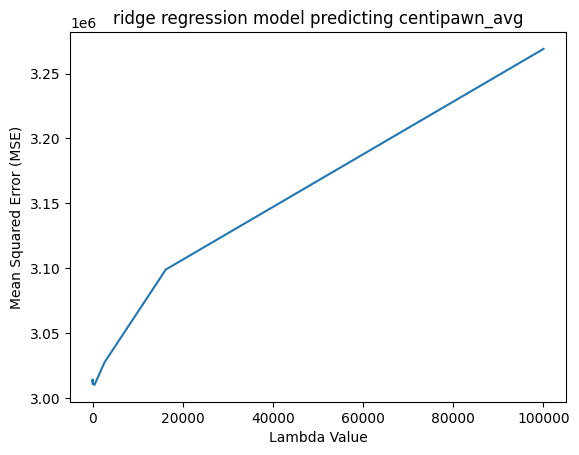

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e+10, tolerance: 4.346e+06
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e+10, tolerance: 4.346e+06
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Optimal Lamda Value: 1.8329807108324374


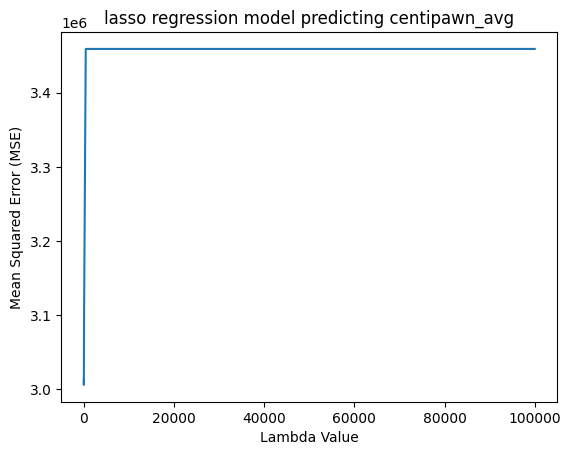

In [34]:
ins = list(chess_data.iloc[:, 19:].columns)
ins.append('turns')
outs = 'centipawn_avg'
runModel(chess_data,ins,outs,'ridge')
runModel(chess_data,ins,outs,'lasso')

The ridge and lasso regressions above concur with the findings of the linear regression model. The MSE of these models is too high to prove viable, and even testing distinct lambda values for the ridge and lasso models proved unhelpful. Average centipawn loss cannot be directly correlated with player ratings or game strategies.


In [35]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
#ins.append('white_rating')
#ins.append('black_rating')
outs = 'winner'
linearModel(chess_data,ins,outs)

Linear model predicting: winner
MSE: 0.27620440212917097
R^2: 0.7103897065126147


The R^2 of the linear regression model for predicting the winner of a game using board analyses data, opening data, centipawn data, and game length, was unexpectedly high at a value of 0.71. While this value is still lower than a viable threshold value, it does indicate that there is some linear correlation between the winner of a game and game strategies or average centipawn loss. This finding makes logical sense, as the more active a player's strategy or the less critical mistakes a player makes, the more likely it is that such a player will win the game. In testing, the addition of player ratings had no effect on the model. This would imply that the patterns of the game are not strictly linearly correlated with the ratings of the players. This means that higher rated players do not necessarily play certain strategies or show certain patterns that lower rater player do not. Such connections cannot be attributed solely to linear regression and require a deeper form of analysis.


Optimal Lamda Value: 11.288378916846883


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.66005818898138e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


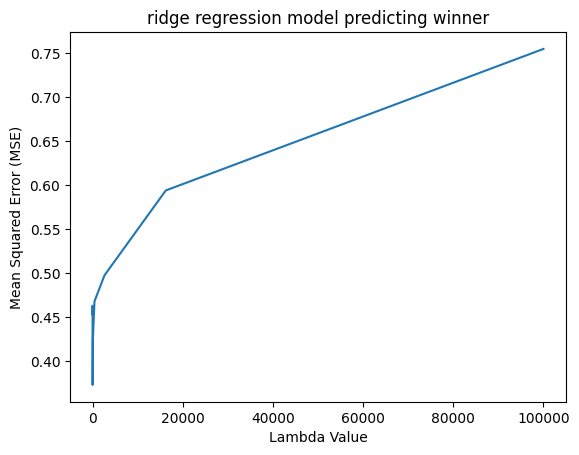

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.822e+03, tolerance: 1.217e+00
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.822e+03, tolerance: 1.217e+00
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Optimal Lamda Value: 0.0012742749857031347


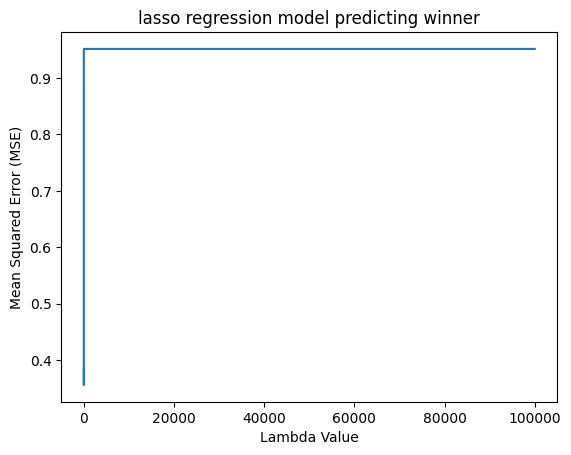

In [36]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
outs = 'winner'
runModel(chess_data,ins,outs,'ridge')
runModel(chess_data,ins,outs,'lasso')

The MSE of the ridge and lasso regression models were in a much more viable scale than the other regression predictions. Both fell within a range of 1, with the best lambda emerging from the ridge regreession at ~11. Through reducing the variance of certain parameters, the linear model was better able to predict the winner of a game in regards to the game strategies played. This provides further relevance to the simple linear model's findings that winner can be estimated through the patterns of gameplay. However, this does not further the claim that such strategies change by rating, as such values were not included in the model for having too little effect.


In [37]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
outs = 'game_rating'
linearModel(chess_data,ins,outs)

Linear model predicting: game_rating
MSE: 55010.32620999205
R^2: 0.20954784598409704


The average rating of a game was also not accurately estimated using a simple linear regression model. Intaking board analyses data, opening data, centipawn data, and game length did not prove viable for estimating player rating. This further supports the previous models' findings that rating is liekly not linearly correlated with game strategies or patterns. The data may be too diverse for such a simple estimation and will require more in-depth analysis for better conclusions.


Optimal Lamda Value: 69.5192796177562


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.66005818898138e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


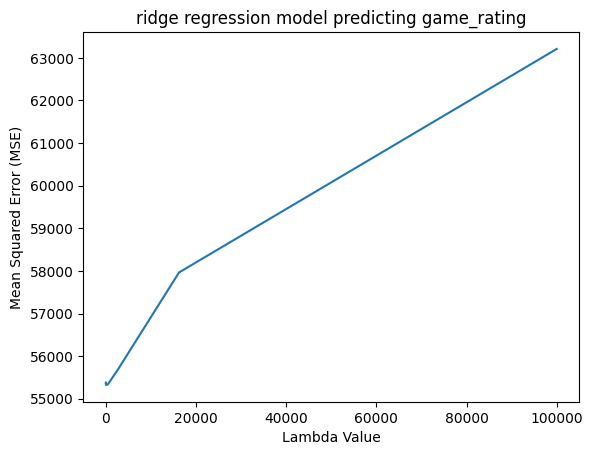

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.509e+08, tolerance: 8.907e+04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.509e+08, tolerance: 8.907e+04
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Optimal Lamda Value: 0.2976351441631313


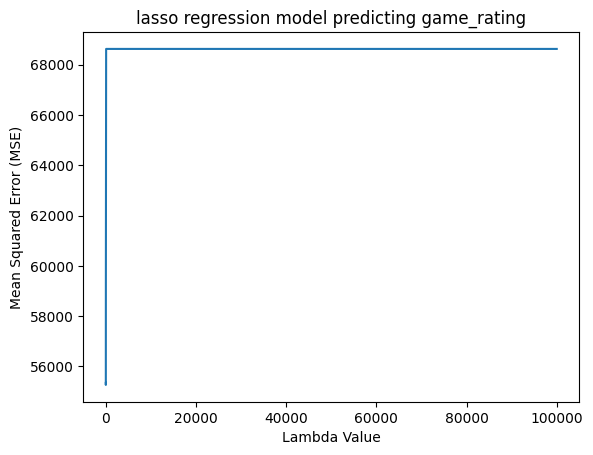

In [38]:
ins = list(chess_data.iloc[:, 16:].columns)
ins.append('turns')
outs = 'game_rating'
runModel(chess_data,ins,outs,'ridge')
runModel(chess_data,ins,outs,'lasso')

Both the ridge and lasso regression models to predict the rating of a game were similarly inefective. The MSE values proved too large for viability. This concludes that simple linear regression models are ineffective at estimating both average centipawn loss and game/player ratings. However, these linear regression models showed promise in estimating the winners of a game. Though, even this showed a relatively unreliable R^2 value of 0.71, indicating that further analysis is needed to to properly correlate game patterns with game winners, and especially for correlating to player ratings.

Additional patterns between players of different ratings were also found in the preliminary analysis that can be viewed in Section 6. Exploratory Analysis. Such findings are listed as follows:

- Overall, board control over the course of the game remained consistent between low, medium, and high ratings.
- Overall, game length remained consistent between low, medium, and high ratings. Data may appear more skewed towards medium rated games lasting longer, however this is an artifact of the data's rating distribution, as there were less low and high rated games in total.
- Overall, proportion of pieces moved remained consistent between low, medium, and high ratings. However, lower rated games saw less rook movement and more queen movement than in medium rated games. The inverse pattern was also observed in higher rated gaes with more rook movement and less queen movement than in medium rated games.
- Overall, the most popular openings remained consistent between low, medium, and high ratings.

The only distinct pattern difference observed was in rook and queen piece control between lower rated and higher rated players. Although this difference was relatively small, it was the only viable pattern identified through the exploratory analysis. Thus, we determine that through simple data visualization, correlation, and regression models, the relationship between gameplay patterns and player rating is generally inconclusive. This may be because this data is difficult to quantify through numbers alone, or because a deeper level of analysis method is required to properly study possibly hidden connections in the data. A broader dataset range may be helpful as well for better encapsulation of lower and higher rated players to make the simple regression estimates and pattern recognition more reliable.


## 9. Answering Question 2

### What correlations or other predictions can be identified based on game data?


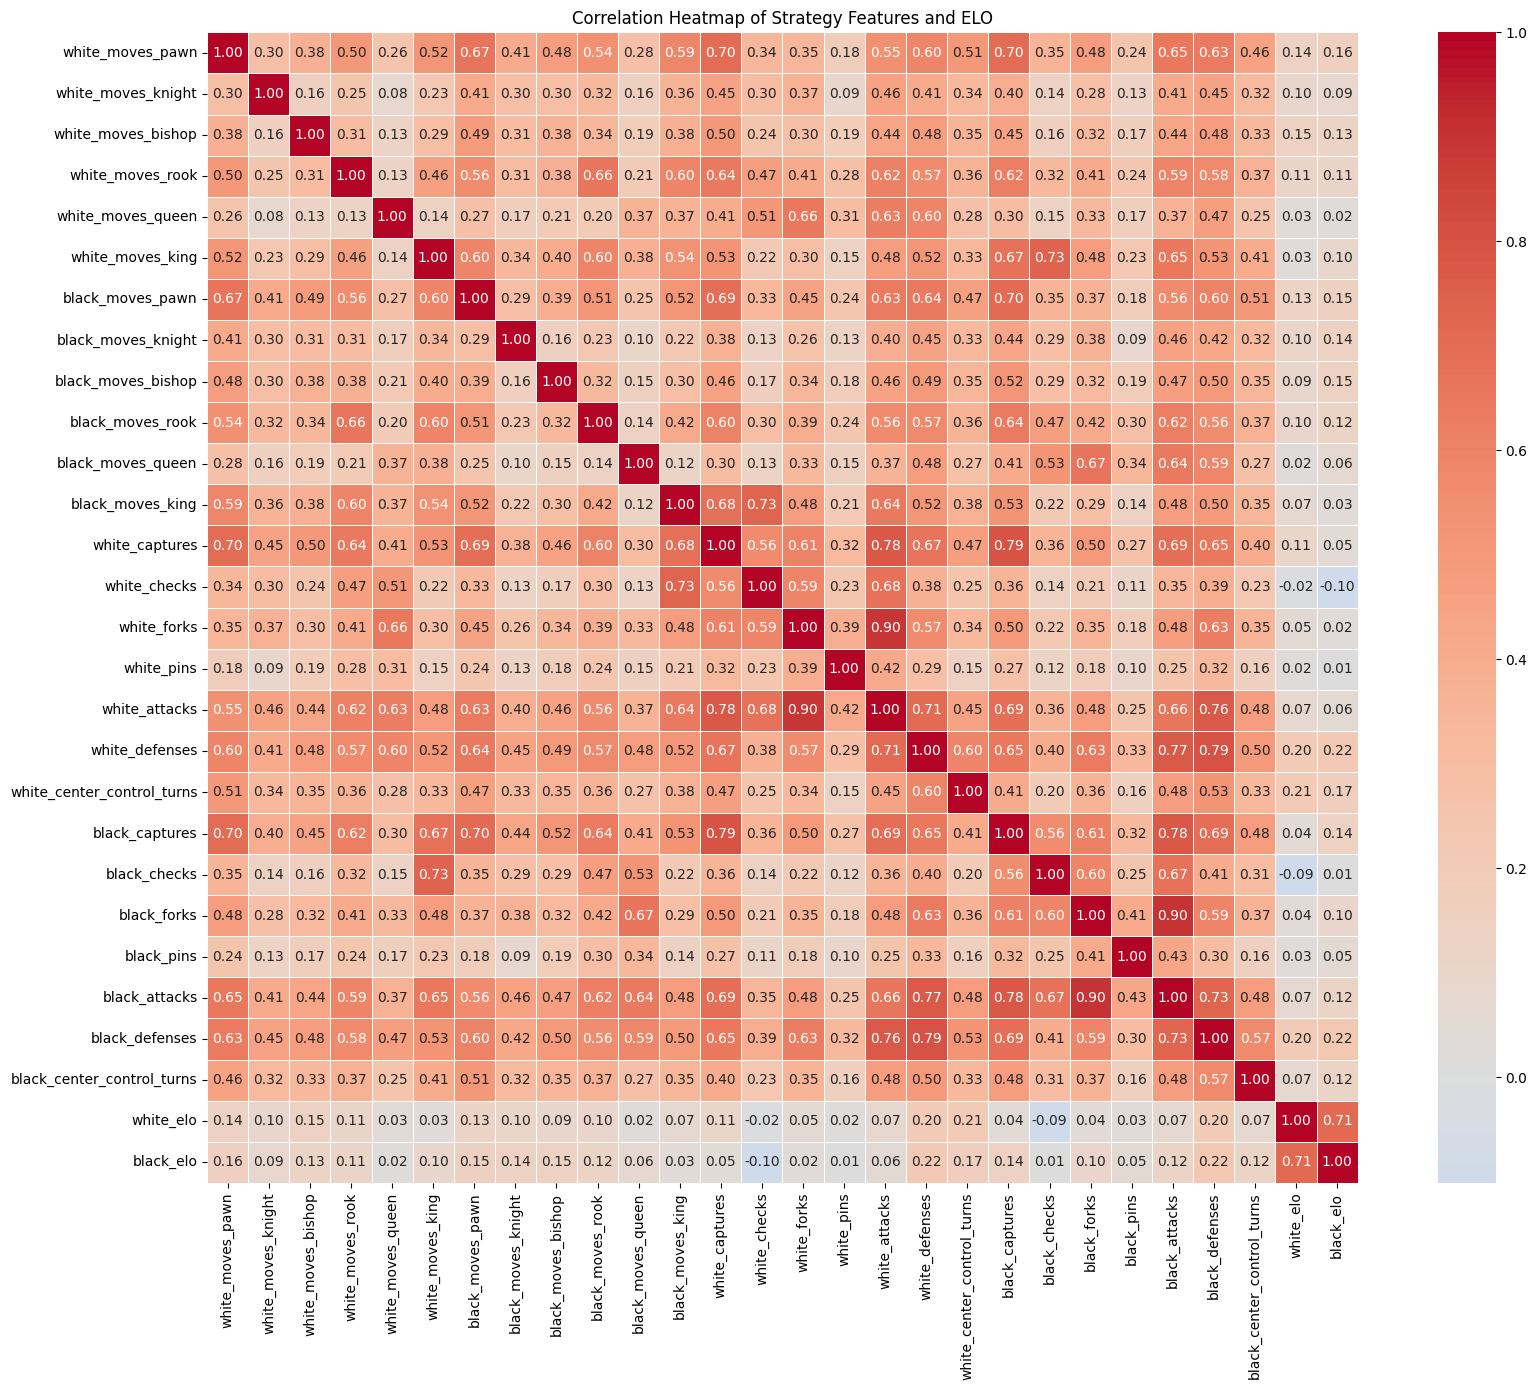

In [39]:
aggregate_strategy_categories = [
    "captures",
    "checks",
    "forks",
    "pins",
    "attacks",
    "defenses",
    "center_control_turns",
]

pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]
move_cols = [
    f"{color}_moves_{piece}"
    for color in ["white", "black"]
    for piece in pieces
]

for color in ["white", "black"]:
    for category in aggregate_strategy_categories:
        matching_cols = [
            col for col in board_analysis_results.columns
            if col.startswith(f"{color}_{category}_")
        ]
        board_analysis_results[f"{color}_{category}"] = board_analysis_results[matching_cols].sum(axis=1)

aggregated_strategy_cols = move_cols + [
    f"{color}_{category}"
    for color in ["white", "black"]
    for category in aggregate_strategy_categories
]

# Find correlation of strategy and ELO
board_analysis_corr = board_analysis_results[aggregated_strategy_cols + ["white_elo", "black_elo"]].corr(numeric_only=True)

# Plot 
plt.figure(figsize=(18, 14))
sns.heatmap(
    board_analysis_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Strategy Features and ELO")
plt.tight_layout()
plt.show()

Figure 2.2.1


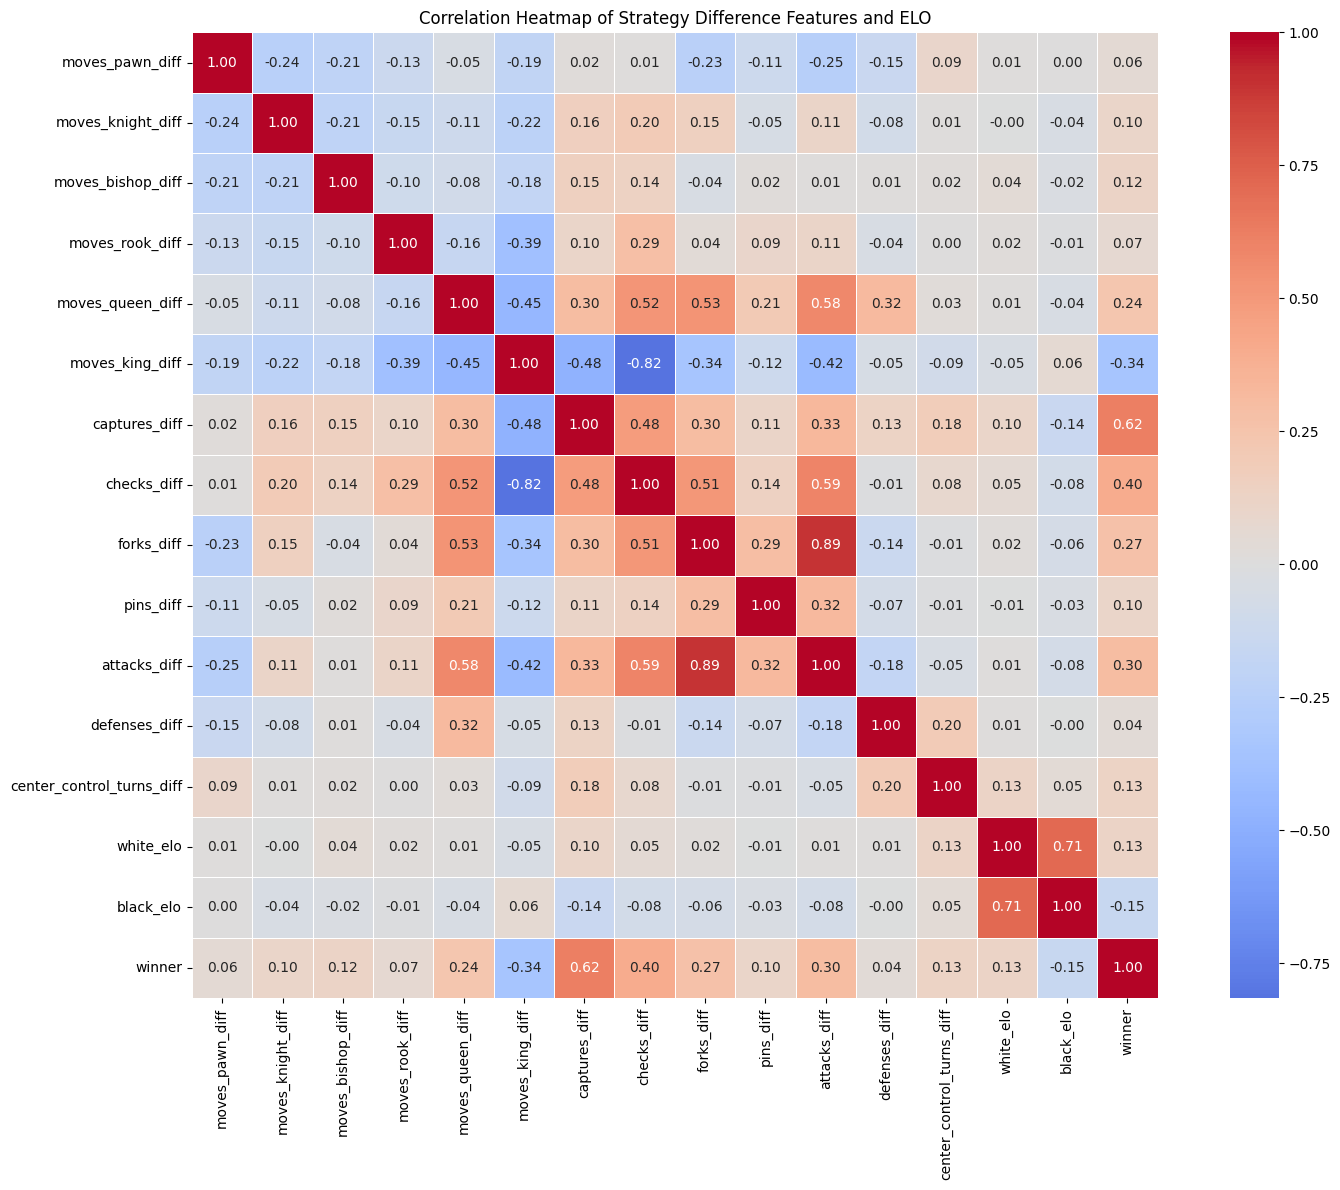

In [40]:
aggregate_strategy_categories = [
    "captures",
    "checks",
    "forks",
    "pins",
    "attacks",
    "defenses",
    "center_control_turns",
]

pieces = ["pawn", "knight", "bishop", "rook", "queen", "king"]

strategy_diff_results = pd.DataFrame()

for piece in pieces:
    strategy_diff_results[f"moves_{piece}_diff"] = (
        board_analysis_results[f"white_moves_{piece}"]
        - board_analysis_results[f"black_moves_{piece}"]
    )

for category in aggregate_strategy_categories:
    white_cols = [
        col for col in board_analysis_results.columns
        if col.startswith(f"white_{category}_")
    ]
    black_cols = [
        col for col in board_analysis_results.columns
        if col.startswith(f"black_{category}_")
    ]

    strategy_diff_results[f"{category}_diff"] = (
        board_analysis_results[white_cols].sum(axis=1)
        - board_analysis_results[black_cols].sum(axis=1)
    )

strategy_diff_results[["white_elo", "black_elo", "winner"]] = board_analysis_results[[
    "white_elo",
    "black_elo",
    "winner",
]]

strategy_diff_corr = strategy_diff_results.corr(numeric_only=True)

# Plot 
plt.figure(figsize=(16, 12))
sns.heatmap(
    strategy_diff_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Strategy Difference Features and ELO")
plt.tight_layout()
plt.show()

Figure 2.2.2


In [41]:
# Use difference of ELO as a predictor
# Do higher ELO players tend to beat lower ELO players?
strategy_diff_results["elo_diff"] = strategy_diff_results["white_elo"] - strategy_diff_results["black_elo"]
strategy_diff_results["elo_diff_pred"] = np.clip((strategy_diff_results["elo_diff"]*1000), -1, 1)

from sklearn.metrics import accuracy_score

acc = accuracy_score(strategy_diff_results["winner"], strategy_diff_results["elo_diff_pred"])
corr = strategy_diff_results["elo_diff"].corr(strategy_diff_results["winner"])

print("Average ELO difference:", np.mean(np.abs(strategy_diff_results["elo_diff"])))

print("Correlation between raw ELO difference and winner:", corr)
print("Accuracy of predictor model:", acc)

Average ELO difference: 151.94047544376843
Correlation between raw ELO difference and winner: 0.365370230048266
Accuracy of predictor model: 0.6156934077651633


##### Conclusions

Using the strategy features dataframe and plotting correlation matrices, there are no clear correlations between strategy and player ELO (Figure 2.2.1). There is slight correlation between white and black defenses and white and black ELO (~0.20). This suggests that on average, higher rated players tend to defend their pieces at a higher rate. This data is consistent with the fact that less skilled players tend to "hang" their pieces. This means that they leave pieces undefended and vulnerable to attack. When pieces are defended, they are less likely to be taken by the oponent unless they are willing to lose material in the exchange. The correlation matrix also shows high correlation between other features that are less interesting to this study.

The second correlation matrix (Figure 2.2.2) displays the difference between white and black on strategy features. This provides insight into the difference of strategy between the players and how that effected game outcome. This matrix demonstrated correlation between captures and victory (victory is classified as -1, 0, and 1). This data tracks logically. If a player takes more material, they are more likely to win the game. There is also slight correlation between checks and victory. This shows that giving checks is a useful baseline strategy. Chess players are often taught to give as many checks as possible because it keeps the player in the driver seat of the game. It forces certain moves from the oponent. This common chess strategy is consistent with the data collected here. Giving more checks than the oponent tends to lead to victory. Forks (when a player moves a piece and attacks >1 piece) and attacks are also somewhat correlated with victory (~0.30). This shows that playing aggresively might be an effective strategy because (on average) the winner tends to attack more than the loser.

ELO was analyzed as a predictor for winner. The rational behind this analysis is to discover whether ELO is a good rating system. On average, players with higher ELOs beat players with lower ELOs. The predictor model predicts the winner purely based off of ELO. If white is higher, prediction is 1, black: -1, and draw: 0. This was compared to the actual winner of the game. This predictive model had an accuracy of around 61%. This means that that ELO is a relatively strong predictor of game output. This validates player ranking. It means that higher ranked players truly are (on average) better chess players (in terms of game outcome).

Overall, there are only a couple of interesting predictors and correlations in this data. These results demonstrate that the chosen strategy metrics may not be useful enough in analyzing chess games. If this study were to be refined, more research could be done into other metrics of chess gameplay to find better predictors of ELO. These results do not bode well for answering question three. It demonstrates a lack of correlation that may hinder a machine learning model from properly predicting ELO.


## 10. Answering Question 3

### Can we use machine learning to predict the rating of a player based purely on a list of moves?


The goal of this section is to discover the feasibility of using machine learning to predict player rating. The core idea is to find a way to boil down chess games to data that is interpretable by a ML model and provide meaningful insights. As discussed throughout this project, chess is incredibly complex and a difficult datascience project. The goal is to take that complexity, and find meaningful ways to simplify it. The attempt to do this was to research the common chess strategies and summarize those for every game (see section 7). Additionally, a chess evaluation engine was used to evaluate (more objectively) how the game was played. This was another input into the models.

The following sections (10.1 - 10.6) are all different machine learning models that use inputs from the intense data processing done earlier. The goal of these models is to perform regression and predict player rating (ELO) based off of move data. The networks consist of variations of the following inputs: board strategy statistics (from section 7), quality of moves (from section 7), and summary statistics of the movement quality data. Movement quality data is given in centipawn loss (a standard way of measuring chess moves). A higher CP means a better move. As an input to the models, the CP data from the first 20 moves of black and white will be given. Although the strategy statistics inputs did not show promise in the previous section (9), the hypothesis is that a neural network will be able to recognize patterns in these data that more simple methods would not recognize. This might allow the NN to accurately predict ELO with the provided data.


In [42]:
board_analysis_results

,white_moves_pawn,white_moves_knight,white_moves_bishop,white_moves_rook,white_moves_queen,white_moves_king,white_captures_pawn,white_captures_knight,white_captures_bishop,white_captures_rook,...,white_attacks,white_defenses,white_center_control_turns,black_captures,black_checks,black_forks,black_pins,black_attacks,black_defenses,black_center_control_turns
idx,,,,,,,,,,,,,,,,,,,,,
1,6,0,0,0,2,0,2,0,0,0,...,8,6,25,3,1,0,0,5,8,9
2,12,3,8,5,3,0,7,1,3,3,...,22,29,39,3,0,3,0,17,27,62
3,4,9,4,3,10,1,1,3,2,0,...,50,49,61,4,0,5,0,27,51,81
4,13,8,3,16,4,4,1,3,1,5,...,37,55,113,10,4,10,2,41,55,95
6,3,4,5,0,4,1,0,2,0,0,...,24,25,18,5,2,5,1,16,16,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,3,4,3,1,0,1,0,1,1,0,...,8,15,29,2,0,0,0,4,11,4
20054,8,11,3,2,8,9,2,3,0,0,...,36,37,75,12,10,11,2,40,54,87
20055,3,6,5,0,4,0,0,0,2,0,...,20,26,44,2,0,0,0,7,30,35


Import Tensorflow and Relevant Libraries

- Using tensorflow because it is flexible and fast
- It will allow us to process the relatively large dataset (13k rows)


In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

#### 10.1. Regression Model Using Board-Strategy Counts and Game Summary Features

This model predicts average game ELO using only engineered board-statistics features from the move list.

Inputs:

- Per-piece action counts for each color, including moves, captures, checks, forks, pins, attacks, defenses, and center occupancy
- Game-level summary counts for each color, including promotions, forced moves, material taken, and material lost
- Outcome and pace context from the finished game, including winner and turn counts
- No centipawn or Stockfish evaluation data

Question: Can ELO be predicted from board-state summary statistics alone, without engine evaluation features?


In [44]:
# ==============================
# Seperate data into X and y
# ==============================

board_analysis_results["game_elo"] = board_analysis_results[["white_elo", "black_elo"]].mean(axis=1)

feature_cols = [
    col for col in board_analysis_results.columns
    if col not in ["white_elo", "black_elo", "game_elo", "idx"]
]
target_cols = ["game_elo"]

X = board_analysis_results[feature_cols].values.astype(np.float32)
y = board_analysis_results[target_cols].values.astype(np.float32)

# ============================================================
# Split data into test, train, and validation
# ============================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================

normalizer = layers.Normalization(axis=-1)
normalizer.adapt(X_train)

# ==============================
# Build model
# ==============================
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    normalizer,
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[keras.metrics.MeanAbsoluteError()]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

# ==============================
# Train
# ==============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
pred = model.predict(X_test, verbose=0)

game_mae = mean_absolute_error(y_test[:, 0], pred[:, 0])
game_rmse = np.sqrt(mean_squared_error(y_test[:, 0], pred[:, 0]))
board_baseline_pred = np.full((len(y_test), 1), y_train_full.mean())
board_baseline_mae = mean_absolute_error(y_test[:, 0], board_baseline_pred[:, 0])
board_baseline_rmse = np.sqrt(mean_squared_error(y_test[:, 0], board_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {game_mae:.2f}")
print(f"Game ELO RMSE: {game_rmse:.2f}")
print(f"Mean baseline MAE:  {board_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {board_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {board_baseline_mae - game_mae:.2f}")
print(f"RMSE improvement over baseline: {board_baseline_rmse - game_rmse:.2f}")

Epoch 1/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 762514.6875 - mean_absolute_error: 689.4540 - val_loss: 151845.9375 - val_mean_absolute_error: 308.1745
Epoch 2/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 125877.1406 - mean_absolute_error: 278.7224 - val_loss: 107667.5859 - val_mean_absolute_error: 259.0145
Epoch 3/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - loss: 101200.9141 - mean_absolute_error: 250.6272 - val_loss: 93028.0391 - val_mean_absolute_error: 240.6521
Epoch 4/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 89646.6719 - mean_absolute_error: 236.9596 - val_loss: 84319.8438 - val_mean_absolute_error: 229.8270
Epoch 5/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 82699.3438 - mean_absolute_error: 228.1859 - val_loss: 79494.8906 - val_mean_absolute_error: 225.0647
Epoch 6/200
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 78363.4375 - mean_absolute_error: 221.9049 - val_loss: 73649.9297 - val_mean_absolute_error: 216.4233
Epoch 7/2

#### 10.2. Regression Model Using the First 20 Centipawn Evaluations Per Side

This model predicts average game ELO from engine-evaluation sequences rather than handcrafted board-strategy counts.

Inputs:

- The first 20 white centipawn evaluations and first 20 black centipawn evaluations from each game
- Centipawn values clamped to reduce the impact of near-checkmate extremes
- Only games long enough to provide at least 20 evaluation points for both sides


In [45]:
import ast

# ==============================
# Data processing
# ==============================

centipawn_data = pd.read_csv("centipawn/centipawn_data_depth_12.csv")

# Clamp values (stockfish provided very high values 100000 and -100000 when checkmate was soon)
centipawn_data["centipawn"] = centipawn_data["centipawn"].apply(ast.literal_eval)
centipawn_data["centipawn"] = centipawn_data["centipawn"].apply(
    lambda values: [max(-1000, min(1000, value)) for value in values]
)

# Sort centipawn by color
centipawn_data["white_centipawn"] = centipawn_data["centipawn"].apply(lambda x: x[::2])
centipawn_data["black_centipawn"] = centipawn_data["centipawn"].apply(lambda x: x[1::2])

# Combine centipawn data with board-analysis features using the explicit index columns
neural_net_with_centipawn = board_analysis_results.merge(
    centipawn_data,
    left_on="idx",
    right_on="index",
    how="inner"
)

centipawn_vector_input = neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 40]

centipawn_vector_input = centipawn_vector_input[["white_centipawn", "black_centipawn", "white_elo", "black_elo"]].copy()
centipawn_vector_input["game_elo"] = centipawn_vector_input[["white_elo", "black_elo"]].mean(axis=1)
centipawn_vector_input

,white_centipawn,black_centipawn,white_elo,black_elo,game_elo
1,"[39, 42, 25, 18, 70, 73, 260, 506, 571, 552, 5...","[-38, 15, -6, -14, -46, -84, -268, -504, -530,...",1496,1500,1498.0
2,"[43, 37, 48, 0, 89, 133, 172, 232, 382, 437, 5...","[-34, -32, 13, -5, -69, -70, -105, -199, -262,...",1439,1454,1446.5
3,"[40, 45, 74, 91, 117, 115, 111, 82, 45, -75, -...","[-45, -43, -72, -88, -118, -115, -82, -43, 55,...",1523,1469,1496.0
5,"[47, 46, 32, 114, 53, 51, 44, 15, 10, 1, -24, ...","[-47, 12, -33, -58, -51, -41, -14, -2, -3, 21,...",1439,1392,1415.5
6,"[36, 76, 82, 89, 180, 175, 59, 159, 184, 106, ...","[-47, -73, -81, -92, -184, -66, -55, -153, -77...",1381,1209,1295.0
...,...,...,...,...,...
15934,"[41, 60, 40, 85, 54, 51, 19, 39, -4, -74, -88,...","[-36, -40, -6, -44, -30, -25, -19, 22, 87, 84,...",1328,1252,1290.0
15936,"[43, 59, 38, 7, -189, 22, -271, -350, -159, -1...","[-38, -35, 13, 254, 181, 277, 324, 442, 184, 3...",1237,1231,1234.0
15939,"[43, 64, 132, 111, 8, 23, 15, 18, 21, -28, 82,...","[-43, -48, 2, -9, -2, -4, -17, -15, 74, 22, 26...",1233,1196,1214.5
15941,"[42, 61, 66, -123, -121, -45, -62, -122, -154,...","[-40, -69, 120, 119, 130, 93, 120, 142, 213, 2...",1360,1227,1293.5


In [46]:
# ==============================
# Flatten first 20 centipawn moves per side
# ==============================
centipawn_vector_input = centipawn_vector_input[
    (centipawn_vector_input["white_centipawn"].apply(len) >= 20) &
    (centipawn_vector_input["black_centipawn"].apply(len) >= 20)
].copy()

white_cp_columns = [f"white_move_{i + 1}" for i in range(20)]
black_cp_columns = [f"black_move_{i + 1}" for i in range(20)]

white_cp_df = pd.DataFrame(
    centipawn_vector_input["white_centipawn"].apply(lambda moves: moves[:20]).tolist(),
    columns=white_cp_columns,
    index=centipawn_vector_input.index
)

black_cp_df = pd.DataFrame(
    centipawn_vector_input["black_centipawn"].apply(lambda moves: moves[:20]).tolist(),
    columns=black_cp_columns,
    index=centipawn_vector_input.index
)

centipawn_flat_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        centipawn_vector_input[["game_elo"]]
    ],
    axis=1
)

centipawn_flat_input.head()

# ==============================
# Prepare data for dense neural net
# ==============================
cp_feature_cols = white_cp_columns + black_cp_columns
cp_target_cols = ["game_elo"]

X_cp = centipawn_flat_input[cp_feature_cols].values.astype(np.float32)
y_cp = centipawn_flat_input[cp_target_cols].values.astype(np.float32)

X_cp_train_full, X_cp_test, y_cp_train_full, y_cp_test = train_test_split(
    X_cp, y_cp, test_size=0.15, random_state=42
)

X_cp_train, X_cp_val, y_cp_train, y_cp_val = train_test_split(
    X_cp_train_full, y_cp_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
cp_normalizer = layers.Normalization(axis=-1)
cp_normalizer.adapt(X_cp_train)

# ==============================
# Build dense centipawn model
# ==============================
cp_model = keras.Sequential([
    keras.Input(shape=(X_cp_train.shape[1],)),
    cp_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

cp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

cp_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    )
]

cp_history = cp_model.fit(
    X_cp_train, y_cp_train,
    validation_data=(X_cp_val, y_cp_val),
    epochs=200,
    batch_size=32,
    callbacks=cp_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
cp_pred = cp_model.predict(X_cp_test, verbose=0)

cp_game_mae = mean_absolute_error(y_cp_test[:, 0], cp_pred[:, 0])
cp_game_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], cp_pred[:, 0]))
cp_baseline_pred = np.full((len(y_cp_test), 1), y_cp_train_full.mean())
cp_baseline_mae = mean_absolute_error(y_cp_test[:, 0], cp_baseline_pred[:, 0])
cp_baseline_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], cp_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {cp_game_mae:.2f}")
print(f"Game ELO RMSE: {cp_game_rmse:.2f}")
print(f"Mean baseline MAE:  {cp_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {cp_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {cp_baseline_mae - cp_game_mae:.2f}")
print(f"RMSE improvement over baseline: {cp_baseline_rmse - cp_game_rmse:.2f}")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2285660.5000 - mean_absolute_error: 1458.1675 - val_loss: 1331598.6250 - val_mean_absolute_error: 1032.7262
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 1212603.0000 - mean_absolute_error: 966.6652 - val_loss: 1058521.0000 - val_mean_absolute_error: 898.4883
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - loss: 911132.7500 - mean_absolute_error: 824.1686 - val_loss: 706132.8125 - val_mean_absolute_error: 717.6908
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step - loss: 528107.6875 - mean_absolute_error: 607.3505 - val_loss: 353425.1875 - val_mean_absolute_error: 489.9623
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 265489.5312 - mean_absolute_error: 414.0233 - val_loss: 179879.1250 - val_mean_absolute_error: 331.5055
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - loss: 155483.6406 - mean_absolute_error: 306.9914 - val_loss: 120925.3047 - val_mean_absolute_error: 268

#### 10.3. Regression Model Using Centipawn Sequences Plus Centipawn Summary Statistics

This version extends the centipawn-sequence model by adding aggregate descriptors of each player's evaluation trend across the game.

Inputs:

- The first 20 white centipawn evaluations and first 20 black centipawn evaluations
- Summary statistics for each side's centipawn series: mean, standard deviation, median, max, and min
- Only games with long enough centipawn histories to support both the sequence and summary features


In [47]:
summary_data = neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 40].copy()
summary_data = summary_data[["white_centipawn", "black_centipawn", "white_elo", "black_elo", "index"]]

white_avg = []
white_std = []
white_median = []
white_max = []
white_min = []

black_avg = []
black_std = []
black_median = []
black_max = []
black_min = []

for idx, row in summary_data.iterrows():
    white_cp = row["white_centipawn"]
    white_avg.append(np.mean(white_cp))
    white_std.append(np.std(white_cp))
    white_median.append(np.median(white_cp))
    white_max.append(np.max(white_cp))
    white_min.append(np.min(white_cp))

    black_cp = row["black_centipawn"]
    black_avg.append(np.mean(black_cp))
    black_std.append(np.std(black_cp))
    black_median.append(np.median(black_cp))
    black_max.append(np.max(black_cp))
    black_min.append(np.min(black_cp))

summary_data["white_avg"] = white_avg
summary_data["white_std"] = white_std
summary_data["white_median"] = white_median
summary_data["white_max"] = white_max
summary_data["white_min"] = white_min

summary_data["black_avg"] = black_avg
summary_data["black_std"] = black_std
summary_data["black_median"] = black_median
summary_data["black_max"] = black_max
summary_data["black_min"] = black_min


summary_input = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        summary_data[["white_avg", "white_std", "white_median", "white_max", "white_min", "black_avg", "black_std", "black_median", "black_max", "black_min"]]
    ],
    axis=1
)

summary_input["game_elo"] = (summary_data["white_elo"] + summary_data["black_elo"]) / 2

In [48]:
# ==============================
# Prepare summary data for dense neural net
# ==============================
summary_feature_cols = [col for col in summary_input.columns if col not in ["game_elo"]]
summary_target_cols = ["game_elo"]

X_summary = summary_input[summary_feature_cols].values.astype(np.float32)
y_summary = summary_input[summary_target_cols].values.astype(np.float32)

X_summary_train_full, X_summary_test, y_summary_train_full, y_summary_test = train_test_split(
    X_summary, y_summary, test_size=0.15, random_state=42
)

X_summary_train, X_summary_val, y_summary_train, y_summary_val = train_test_split(
    X_summary_train_full, y_summary_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
summary_normalizer = layers.Normalization(axis=-1)
summary_normalizer.adapt(X_summary_train)

# ==============================
# Build combined model
# ==============================
summary_model = keras.Sequential([
    keras.Input(shape=(X_summary_train.shape[1],)),
    summary_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

summary_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

summary_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

summary_history = summary_model.fit(
    X_summary_train, y_summary_train,
    validation_data=(X_summary_val, y_summary_val),
    epochs=200,
    batch_size=32,
    callbacks=summary_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
summary_pred = summary_model.predict(X_summary_test, verbose=0)

summary_game_mae = mean_absolute_error(y_summary_test[:, 0], summary_pred[:, 0])
summary_game_rmse = np.sqrt(mean_squared_error(y_summary_test[:, 0], summary_pred[:, 0]))
summary_baseline_pred = np.full((len(y_summary_test), 1), y_summary_train_full.mean())
summary_baseline_mae = mean_absolute_error(y_summary_test[:, 0], summary_baseline_pred[:, 0])
summary_baseline_rmse = np.sqrt(mean_squared_error(y_summary_test[:, 0], summary_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {summary_game_mae:.2f}")
print(f"Game ELO RMSE: {summary_game_rmse:.2f}")
print(f"Mean baseline MAE:  {summary_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {summary_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {summary_baseline_mae - summary_game_mae:.2f}")
print(f"RMSE improvement over baseline: {summary_baseline_rmse - summary_game_rmse:.2f}")

# Save best-performing model
os.makedirs("weights", exist_ok=True)
summary_model.save("weights/flattened_centipawn_summary.keras")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1377877.7500 - mean_absolute_error: 1036.2562 - val_loss: 406784.0312 - val_mean_absolute_error: 525.5768
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 183287.2812 - mean_absolute_error: 333.2048 - val_loss: 93471.2969 - val_mean_absolute_error: 240.5797
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 93624.9219 - mean_absolute_error: 242.2366 - val_loss: 72062.5859 - val_mean_absolute_error: 214.1131
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 78994.1719 - mean_absolute_error: 223.0239 - val_loss: 64001.1875 - val_mean_absolute_error: 201.9950
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 70683.9922 - mean_absolute_error: 211.3824 - val_loss: 59029.2852 - val_mean_absolute_error: 193.8782
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - loss: 65460.9180 - mean_absolute_error: 204.2497 - val_loss: 54980.1328 - val_mean_absolute_error: 188.0068
Epoch 7

#### 10.4. Regression Model Using Board-Strategy Features and Raw Centipawn Sequences

This model combines handcrafted board-statistics features with raw centipawn move-evaluation sequences to test whether the two feature types complement each other.

Inputs:

- Per-piece board-strategy counts for each color, including moves, captures, checks, forks, pins, attacks, defenses, and center occupancy
- Game-level summary counts, winner, victory status, opening metadata, and other completed-game context retained in the merged feature table
- The first 20 white centipawn evaluations and first 20 black centipawn evaluations


In [49]:
combined_board_analysis_results = pd.concat(
    [
        white_cp_df,
        black_cp_df,
        neural_net_with_centipawn[neural_net_with_centipawn["total_turns"] >= 40]
    ],
    axis=1
)

combined_board_analysis_results["game_elo"] = combined_board_analysis_results[["white_elo", "black_elo"]].mean(axis=1)
combined_board_analysis_results = combined_board_analysis_results.drop(columns=["centipawn", "black_centipawn", "white_centipawn", "index","total_turns", "white_turns", "black_turns"])
combined_board_analysis_results

,white_move_1,white_move_2,white_move_3,white_move_4,white_move_5,white_move_6,white_move_7,white_move_8,white_move_9,white_move_10,...,white_defenses,white_center_control_turns,black_captures,black_checks,black_forks,black_pins,black_attacks,black_defenses,black_center_control_turns,game_elo
1,39,42,25,18,70,73,260,506,571,552,...,29,39,3,0,3,0,17,27,62,1498.0
2,43,37,48,0,89,133,172,232,382,437,...,49,61,4,0,5,0,27,51,81,1446.5
3,40,45,74,91,117,115,111,82,45,-75,...,55,113,10,4,10,2,41,55,95,1496.0
5,47,46,32,114,53,51,44,15,10,1,...,51,68,8,6,12,2,42,47,67,1415.5
6,36,76,82,89,180,175,59,159,184,106,...,45,57,13,9,13,2,44,56,16,1295.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15934,41,60,40,85,54,51,19,39,-4,-74,...,27,46,8,1,7,1,25,20,41,1290.0
15936,43,59,38,7,-189,22,-271,-350,-159,-181,...,37,29,7,6,10,4,31,28,65,1234.0
15939,43,64,132,111,8,23,15,18,21,-28,...,37,75,12,10,11,2,40,54,87,1214.5
15941,42,61,66,-123,-121,-45,-62,-122,-154,-199,...,31,85,11,6,5,0,36,36,53,1293.5


In [50]:
# ==============================
# Prepare combined data for dense neural net
# ==============================
combined_feature_cols = [col for col in combined_board_analysis_results.columns if col not in ["white_elo", "black_elo", "game_elo"]]
combined_target_cols = ["game_elo"]

X_combined = combined_board_analysis_results[combined_feature_cols].values.astype(np.float32)
y_combined = combined_board_analysis_results[combined_target_cols].values.astype(np.float32)

X_combined_train_full, X_combined_test, y_combined_train_full, y_combined_test = train_test_split(
    X_combined, y_combined, test_size=0.15, random_state=42
)

X_combined_train, X_combined_val, y_combined_train, y_combined_val = train_test_split(
    X_combined_train_full, y_combined_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
combined_normalizer = layers.Normalization(axis=-1)
combined_normalizer.adapt(X_combined_train)

# ==============================
# Build combined model
# ==============================
combined_model = keras.Sequential([
    keras.Input(shape=(X_combined_train.shape[1],)),
    combined_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

combined_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

combined_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    )
]

combined_history = combined_model.fit(
    X_combined_train, y_combined_train,
    validation_data=(X_combined_val, y_combined_val),
    epochs=200,
    batch_size=32,
    callbacks=combined_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
combined_pred = combined_model.predict(X_combined_test, verbose=0)

combined_game_mae = mean_absolute_error(y_combined_test[:, 0], combined_pred[:, 0])
combined_game_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 0], combined_pred[:, 0]))
combined_baseline_pred = np.full((len(y_combined_test), 1), y_combined_train_full.mean())
combined_baseline_mae = mean_absolute_error(y_combined_test[:, 0], combined_baseline_pred[:, 0])
combined_baseline_rmse = np.sqrt(mean_squared_error(y_combined_test[:, 0], combined_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {combined_game_mae:.2f}")
print(f"Game ELO RMSE: {combined_game_rmse:.2f}")
print(f"Mean baseline MAE:  {combined_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {combined_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {combined_baseline_mae - combined_game_mae:.2f}")
print(f"RMSE improvement over baseline: {combined_baseline_rmse - combined_game_rmse:.2f}")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2292883.7500 - mean_absolute_error: 1471.0637 - val_loss: 950044.9375 - val_mean_absolute_error: 890.1973
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 521519.9375 - mean_absolute_error: 595.6921 - val_loss: 360367.1250 - val_mean_absolute_error: 482.4157
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 304395.4375 - mean_absolute_error: 446.5746 - val_loss: 245647.3750 - val_mean_absolute_error: 389.9517
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - loss: 212978.5312 - mean_absolute_error: 366.4168 - val_loss: 184894.4688 - val_mean_absolute_error: 334.6837
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 170079.7812 - mean_absolute_error: 327.0069 - val_loss: 153794.9219 - val_mean_absolute_error: 303.9660
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: 144999.7969 - mean_absolute_error: 301.2992 - val_loss: 133891.9531 - val_mean_absolute_error: 282.9975
Ep

#### 10.5. Regression Model Using Board-Strategy Features and Centipawn Summary Statistics

This final model uses engineered strategic board features together with aggregate centipawn descriptors, without including the full centipawn move sequence.

Inputs:

- Per-piece board-strategy counts for each color, including moves, captures, checks, forks, pins, attacks, defenses, and center occupancy
- Summary statistics for white and black centipawn trajectories: mean, standard deviation, median, max, and min
- Average game ELO as the prediction target


In [51]:
# ==============================
# Combine board strategy stats with centipawn summary stats
# ==============================
board_strategy_cols = [
    col for col in board_analysis_results.columns
    if col not in ["white_elo", "black_elo", "game_elo", "winner", "total_turns", "white_turns", "black_turns", "idx", "average_elo", "rating_bucket"]
]

centipawn_summary_cols = [
    "white_avg", "white_std", "white_median", "white_max", "white_min",
    "black_avg", "black_std", "black_median", "black_max", "black_min"
]

strategy_summary_input = pd.concat(
    [
        neural_net_with_centipawn.loc[summary_data.index, board_strategy_cols].reset_index(drop=True),
        summary_data[centipawn_summary_cols].reset_index(drop=True)
    ],
    axis=1
)

strategy_summary_input["game_elo"] = (
    summary_data["white_elo"].reset_index(drop=True) +
    summary_data["black_elo"].reset_index(drop=True)
) / 2

# ==============================
# Prepare data for dense neural net
# ==============================
strategy_summary_feature_cols = [col for col in strategy_summary_input.columns if col != "game_elo"]
strategy_summary_target_cols = ["game_elo"]

X_strategy_summary = strategy_summary_input[strategy_summary_feature_cols].values.astype(np.float32)
y_strategy_summary = strategy_summary_input[strategy_summary_target_cols].values.astype(np.float32)

X_strategy_summary_train_full, X_strategy_summary_test, y_strategy_summary_train_full, y_strategy_summary_test = train_test_split(
    X_strategy_summary, y_strategy_summary, test_size=0.15, random_state=42
)

X_strategy_summary_train, X_strategy_summary_val, y_strategy_summary_train, y_strategy_summary_val = train_test_split(
    X_strategy_summary_train_full, y_strategy_summary_train_full, test_size=0.15, random_state=42
)

# ===================================
# Create normalization layer (scaling)
# ===================================
strategy_summary_normalizer = layers.Normalization(axis=-1)
strategy_summary_normalizer.adapt(X_strategy_summary_train)

# ==============================
# Build model
# ==============================
strategy_summary_model = keras.Sequential([
    keras.Input(shape=(X_strategy_summary_train.shape[1],)),
    strategy_summary_normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

strategy_summary_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

strategy_summary_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

strategy_summary_history = strategy_summary_model.fit(
    X_strategy_summary_train, y_strategy_summary_train,
    validation_data=(X_strategy_summary_val, y_strategy_summary_val),
    epochs=200,
    batch_size=32,
    callbacks=strategy_summary_callbacks,
    verbose=1
)

# ==============================
# Evaluate
# ==============================
strategy_summary_pred = strategy_summary_model.predict(X_strategy_summary_test, verbose=0)

strategy_summary_mae = mean_absolute_error(y_strategy_summary_test[:, 0], strategy_summary_pred[:, 0])
strategy_summary_rmse = np.sqrt(mean_squared_error(y_strategy_summary_test[:, 0], strategy_summary_pred[:, 0]))
strategy_summary_baseline_pred = np.full((len(y_strategy_summary_test), 1), y_strategy_summary_train_full.mean())
strategy_summary_baseline_mae = mean_absolute_error(y_strategy_summary_test[:, 0], strategy_summary_baseline_pred[:, 0])
strategy_summary_baseline_rmse = np.sqrt(mean_squared_error(y_strategy_summary_test[:, 0], strategy_summary_baseline_pred[:, 0]))

print(f"Game ELO MAE:  {strategy_summary_mae:.2f}")
print(f"Game ELO RMSE: {strategy_summary_rmse:.2f}")
print(f"Mean baseline MAE:  {strategy_summary_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {strategy_summary_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {strategy_summary_baseline_mae - strategy_summary_mae:.2f}")
print(f"RMSE improvement over baseline: {strategy_summary_baseline_rmse - strategy_summary_rmse:.2f}")


Epoch 1/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1021649.5625 - mean_absolute_error: 817.0006 - val_loss: 171119.0938 - val_mean_absolute_error: 319.6406
Epoch 2/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 149239.2188 - mean_absolute_error: 305.0841 - val_loss: 115965.8359 - val_mean_absolute_error: 264.7481
Epoch 3/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 112762.7734 - mean_absolute_error: 264.7812 - val_loss: 97816.8516 - val_mean_absolute_error: 240.9871
Epoch 4/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - loss: 96486.2734 - mean_absolute_error: 245.9309 - val_loss: 83312.3750 - val_mean_absolute_error: 224.7731
Epoch 5/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - loss: 87320.8750 - mean_absolute_error: 233.8945 - val_loss: 75556.5781 - val_mean_absolute_error: 214.8764
Epoch 6/200
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step - loss: 78943.4844 - mean_absolute_error: 223.5461 - val_loss: 71833.0156 - val_mean_absolute_error: 210.0619
Epoch 

In [52]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# ==============================
# Support Vector Regressor baselines
# ==============================
board_svr = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=100, epsilon=10)
)

board_svr.fit(X_train, y_train.ravel())
board_svr_pred = board_svr.predict(X_test)

board_svr_mae = mean_absolute_error(y_test[:, 0], board_svr_pred)
board_svr_rmse = np.sqrt(mean_squared_error(y_test[:, 0], board_svr_pred))

print(f"Board statistics SVR MAE:  {board_svr_mae:.2f}")
print(f"Board statistics SVR RMSE: {board_svr_rmse:.2f}")
print(f"Mean baseline MAE:  {board_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {board_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {board_baseline_mae - board_svr_mae:.2f}")
print(f"RMSE improvement over baseline: {board_baseline_rmse - board_svr_rmse:.2f}")


centipawn_svr = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=100, epsilon=10)
)

centipawn_svr.fit(X_cp_train, y_cp_train.ravel())
centipawn_svr_pred = centipawn_svr.predict(X_cp_test)

centipawn_svr_mae = mean_absolute_error(y_cp_test[:, 0], centipawn_svr_pred)
centipawn_svr_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], centipawn_svr_pred))

print(f"Raw centipawn SVR MAE:  {centipawn_svr_mae:.2f}")
print(f"Raw centipawn SVR RMSE: {centipawn_svr_rmse:.2f}")
print(f"Mean baseline MAE:  {cp_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {cp_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {cp_baseline_mae - centipawn_svr_mae:.2f}")
print(f"RMSE improvement over baseline: {cp_baseline_rmse - centipawn_svr_rmse:.2f}")


board_pca_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95),
    LinearRegression()
)

board_pca_lr.fit(X_train, y_train.ravel())
board_pca_lr_pred = board_pca_lr.predict(X_test)

board_pca_lr_mae = mean_absolute_error(y_test[:, 0], board_pca_lr_pred)
board_pca_lr_rmse = np.sqrt(mean_squared_error(y_test[:, 0], board_pca_lr_pred))

print(f"Board statistics PCA + Linear Regression MAE:  {board_pca_lr_mae:.2f}")
print(f"Board statistics PCA + Linear Regression RMSE: {board_pca_lr_rmse:.2f}")
print(f"Mean baseline MAE:  {board_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {board_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {board_baseline_mae - board_pca_lr_mae:.2f}")
print(f"RMSE improvement over baseline: {board_baseline_rmse - board_pca_lr_rmse:.2f}")


centipawn_pca_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95),
    LinearRegression()
)

centipawn_pca_lr.fit(X_cp_train, y_cp_train.ravel())
centipawn_pca_lr_pred = centipawn_pca_lr.predict(X_cp_test)

centipawn_pca_lr_mae = mean_absolute_error(y_cp_test[:, 0], centipawn_pca_lr_pred)
centipawn_pca_lr_rmse = np.sqrt(mean_squared_error(y_cp_test[:, 0], centipawn_pca_lr_pred))

print(f"Raw centipawn PCA + Linear Regression MAE:  {centipawn_pca_lr_mae:.2f}")
print(f"Raw centipawn PCA + Linear Regression RMSE: {centipawn_pca_lr_rmse:.2f}")
print(f"Mean baseline MAE:  {cp_baseline_mae:.2f}")
print(f"Mean baseline RMSE: {cp_baseline_rmse:.2f}")
print(f"MAE improvement over baseline:  {cp_baseline_mae - centipawn_pca_lr_mae:.2f}")
print(f"RMSE improvement over baseline: {cp_baseline_rmse - centipawn_pca_lr_rmse:.2f}")


Board statistics SVR MAE:  180.37
Board statistics SVR RMSE: 228.66
Mean baseline MAE:  211.39
Mean baseline RMSE: 260.41
MAE improvement over baseline:  31.02
RMSE improvement over baseline: 31.75
Raw centipawn SVR MAE:  169.00
Raw centipawn SVR RMSE: 211.76
Mean baseline MAE:  207.60
Mean baseline RMSE: 256.35
MAE improvement over baseline:  38.60
RMSE improvement over baseline: 44.59
Board statistics PCA + Linear Regression MAE:  187.72
Board statistics PCA + Linear Regression RMSE: 234.69
Mean baseline MAE:  211.39
Mean baseline RMSE: 260.41
MAE improvement over baseline:  23.67
RMSE improvement over baseline: 25.72
Raw centipawn PCA + Linear Regression MAE:  186.75
Raw centipawn PCA + Linear Regression RMSE: 230.68
Mean baseline MAE:  207.60
Mean baseline RMSE: 256.35
MAE improvement over baseline:  20.85
RMSE improvement over baseline: 25.66


#### 10.6. Regression Model Error Comparison

This section compares the regression models directly using test-set MAE and RMSE. The bucket-classification model is excluded because it does not produce regression errors.


,model,mae,rmse,baseline_mae,baseline_rmse,mae_improvement_vs_baseline,rmse_improvement_vs_baseline
0,Centipawn sequence + summary stats,166.839203,207.712175,207.597778,256.346979,40.758575,48.634804
1,Raw centipawn SVR,168.995331,211.761206,207.597778,256.346979,38.602448,44.585773
2,Raw centipawn sequence,170.954865,211.233736,207.597778,256.346979,36.642914,45.113242
3,Board strategy + raw centipawn,172.608551,217.444264,207.597778,256.346979,34.989227,38.902715
4,Board strategy + centipawn summary,176.423615,224.502801,207.597778,256.346979,31.174164,31.844177
5,Board statistics SVR,180.366284,228.658249,211.389664,260.412953,31.023379,31.754704
6,Raw centipawn PCA + Linear Regression,186.745621,230.683563,207.597778,256.346979,20.852158,25.663416
7,Board statistics PCA + Linear Regression,187.720642,234.690729,211.389664,260.412953,23.669022,25.722224
8,Board strategy + game summary,191.536743,242.632857,211.389664,260.412953,19.852921,17.780097


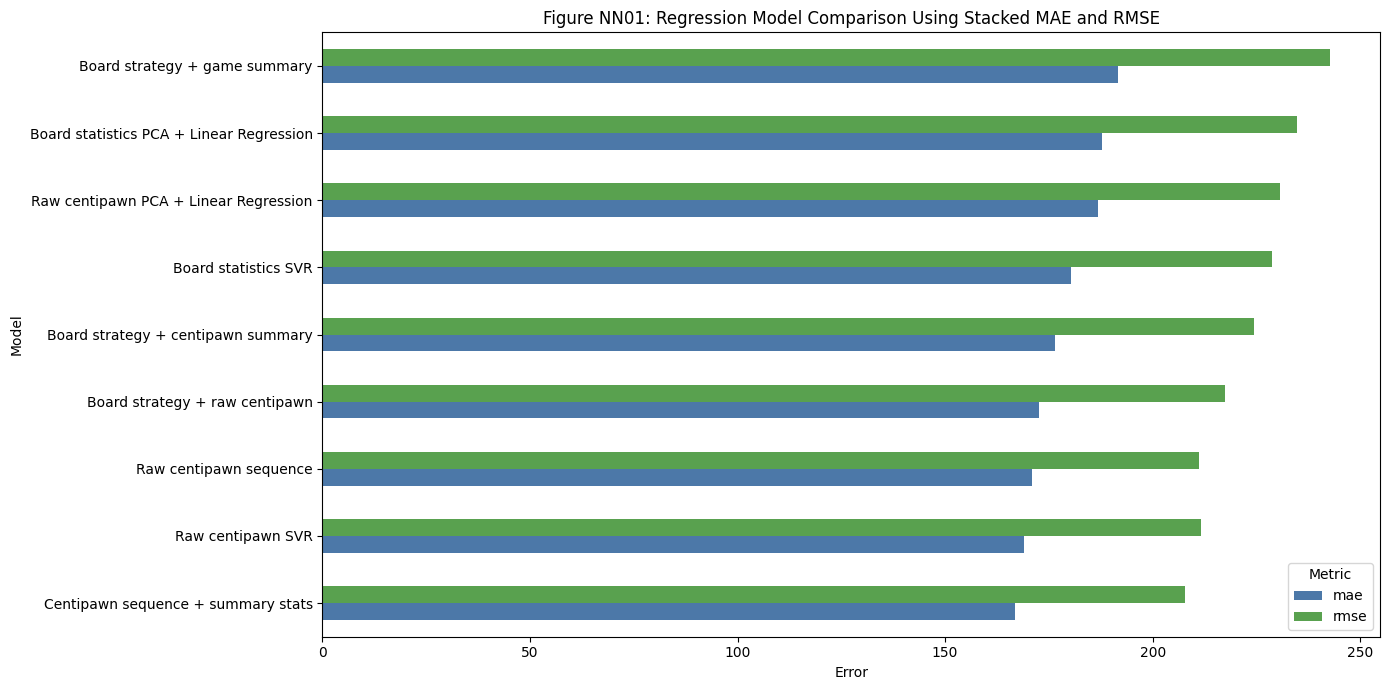

In [53]:
model_comparison_df = pd.DataFrame(
    {
        "model": [
            "Board strategy + game summary",
            "Board statistics SVR",
            "Board statistics PCA + Linear Regression",
            "Raw centipawn sequence",
            "Raw centipawn SVR",
            "Raw centipawn PCA + Linear Regression",
            "Centipawn sequence + summary stats",
            "Board strategy + raw centipawn",
            "Board strategy + centipawn summary",
        ],
        "mae": [
            game_mae,
            board_svr_mae,
            board_pca_lr_mae,
            cp_game_mae,
            centipawn_svr_mae,
            centipawn_pca_lr_mae,
            summary_game_mae,
            combined_game_mae,
            strategy_summary_mae,
        ],
        "rmse": [
            game_rmse,
            board_svr_rmse,
            board_pca_lr_rmse,
            cp_game_rmse,
            centipawn_svr_rmse,
            centipawn_pca_lr_rmse,
            summary_game_rmse,
            combined_game_rmse,
            strategy_summary_rmse,
        ],
        "baseline_mae": [
            board_baseline_mae,
            board_baseline_mae,
            board_baseline_mae,
            cp_baseline_mae,
            cp_baseline_mae,
            cp_baseline_mae,
            summary_baseline_mae,
            combined_baseline_mae,
            strategy_summary_baseline_mae,
        ],
        "baseline_rmse": [
            board_baseline_rmse,
            board_baseline_rmse,
            board_baseline_rmse,
            cp_baseline_rmse,
            cp_baseline_rmse,
            cp_baseline_rmse,
            summary_baseline_rmse,
            combined_baseline_rmse,
            strategy_summary_baseline_rmse,
        ],
    }
)

model_comparison_df["mae_improvement_vs_baseline"] = model_comparison_df["baseline_mae"] - model_comparison_df["mae"]
model_comparison_df["rmse_improvement_vs_baseline"] = model_comparison_df["baseline_rmse"] - model_comparison_df["rmse"]

model_comparison_df = model_comparison_df.sort_values("mae").reset_index(drop=True)
display(model_comparison_df)

plot_df = model_comparison_df.set_index("model")[["mae", "rmse"]]

ax = plot_df.plot(
    kind="barh",
    stacked=False,
    figsize=(14, 7),
    color=["#4C78A8", "#59A14F"]
)

ax.set_title("Figure NN01: Regression Model Comparison Using Stacked MAE and RMSE")
ax.set_xlabel("Error")
ax.set_ylabel("Model")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()


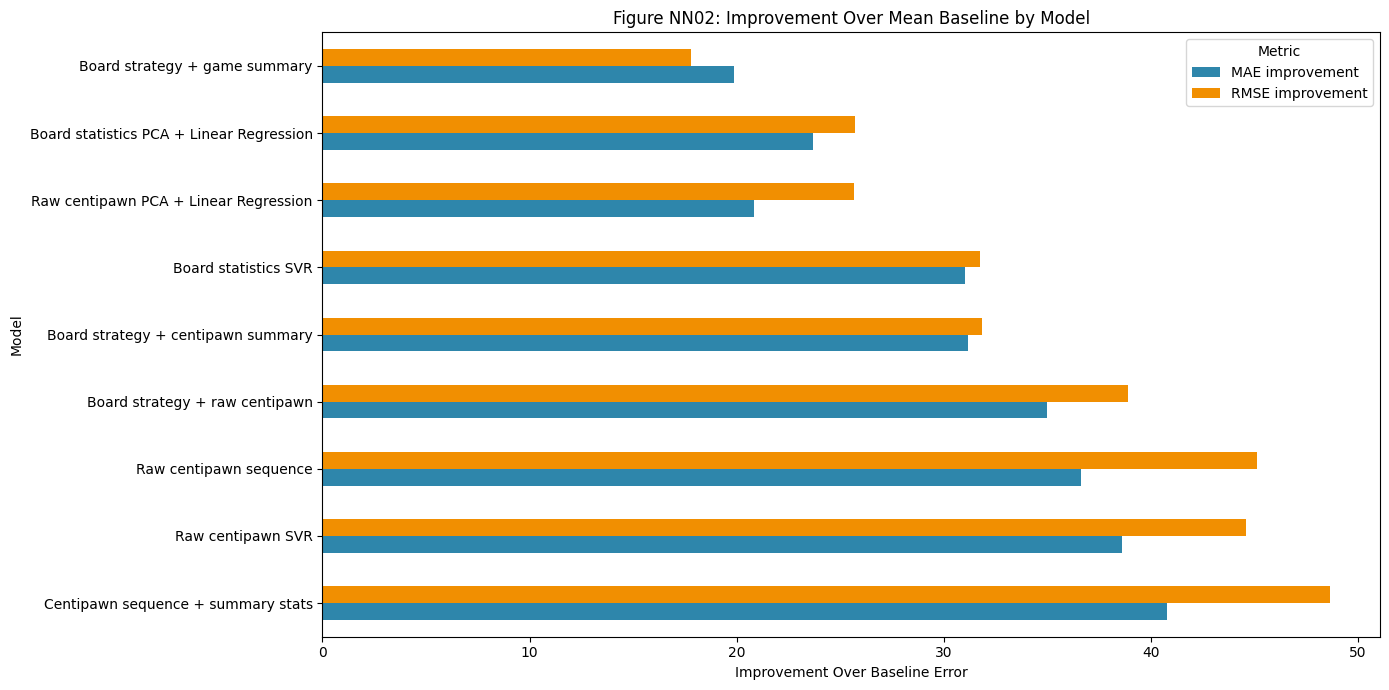

In [54]:
improvement_plot_df = model_comparison_df.set_index("model")[
    ["mae_improvement_vs_baseline", "rmse_improvement_vs_baseline"]
]

ax = improvement_plot_df.plot(
    kind="barh",
    figsize=(14, 7),
    color=["#2E86AB", "#F18F01"]
)

ax.set_title("Figure NN02: Improvement Over Mean Baseline by Model")
ax.set_xlabel("Improvement Over Baseline Error")
ax.set_ylabel("Model")
ax.legend(["MAE improvement", "RMSE improvement"], title="Metric")
plt.tight_layout()
plt.show()


#### 10.7. Results

Figure NN01 shows the MAE and RMSE of all the models. It demonstrates slight differencesw between model inputs. The best performing models were the ones with the Raw centipawn data of the first 40 moves. Out of these models, the centipawn sequence and centipawn summary statistics performed the best with a MAE of 167 and an RMSE of 208. The performance range was tight with a MAE range of 167-188 and a RMSE range of 208-211.

Figure NN02 shows the predictive power over baseline of all the models. It further demonstrates that the raw centipawn sequence and the centipawn summary statistics were the optimal inputs for the model. This model gave the best improvement over baseline for MAE and RMSE.

#### 10.8. Conclusions

This data demonstrates that predicting ELO based off of the different input statistics is very challenging. The hypothesis that the neural network would be able to pick up on patterns not recognized by other methodologies was not validated. Support vector regression and linear regression gave similar results in terms of performance. Linear regression performed the worst; however, it was still in the same range of performance. The neural network was not able to successful pick up on patterns in the data to predict player rating. This could be for a number of reasons. For starters, it is quite possible that the amount of data was insufficient. The model was fed around \_\_\_ of training data. It is possible that it needed an order of magnitude more data to sort through the noise and properly train the model to predict rating. Another reason for its shortcomings could be that the data being input was not correlated enough to player rating. The inputs that were chosen were selected carefully, but that does not guarantee a working model.


#### 10.9. Interactive ELO Guesser

Although the model was not successful at guessing ELO, an interactive ELO guesser was developed. It is highly inaccurate, but demonstrates that the model can take chess input and output a guess. It is an interactive web app created in [Flask](https://flask.palletsprojects.com/en/stable/). It uses the strongest model (centipawn sequence + centipawn summary statistics)

- To run it, install flask to your python environment: `pip install flask`. Ensure that stockfish is installed: https://stockfishchess.org/download/

- Run:
  ```bash
  export FLASK_APP=interactive/app.py
  flask run
  ```
- Then navigate to: http://127.0.0.1:5000/

- You should be greeted with this screen:

  ![](./gte.png)

- Now choose a .pgn file. This is a standard way to store chess games. You can download these files from Chess.com, Lichess.org, or chess game analysis websites. Click "Guess" and it will run the neural network to try to guess the average ELO of the players participating in the game.


## 11. Summary and Conclusions

#### 11.1. Limitations

As mentioned multiple times before, the analysis methodologies used in this project were not particularly effective at drawing conclusions from the dataset. Even after researching chess tactics, strategies, and gameplay styles, we were unable to extract meaningful insights using the data provided. This is most likely due to the nature of chess. Chess is a complex game that is hard to extract specific "signals" from. Although the dataset was relatively large (containing several thousand games), the range of the data was not enough to conclusively determine gameplay strategies for players of various ratings. A larger scale dataset would be helpful for future analyses to not only provide more points of data, but to encapsulate a broader range of data, such as more extreme lower and higher rated games.

#### 11.2. Project Summary

This project aimed to analyze chess using datascience methodologies. This goal was acheived, however, the conclusions drawn were not particularly insightful and the limitations of the dataset were apparent at multiple junctures. Over the course of the project, research questions had to be changed or refined because of the inherent limitations of the dataset. The most meaningful and useful data is in an unusable form in the original dataset. That is, movement data, is a string that must be analyzed by a virtual chess board. For this reason, heavy data processing had to be done on the dataset to try to draw conclusions about tactics and strategies. Once this was done, there were several interesting conclusions drawn from this new dataframe. Namely, there is very low correlation between basic chess tactics and player ratings. This demonstrates that players of all skill levels utilized strategies in a similar manner. This then implies that there were no strategies (that were analyzed) that were used more by high ranking players. This demonstrates the complexity of the problem. Chess games, patterns, and strategies are difficult to simplify into pure data. It is intangible. Intuitively, a higher ranking chess player is going to have a more sophisticated strategy than a lower ranking player, but this nuance is difficult to capture with numbers.

The most useful analysis methodology was Stockfish analysis. This was another heavy data processing task, as Stockfish analysis was run on every row of the dataset, spanning multiple hours to complete all iterations. This data was the most strongly correlated with player rating. This is unsuprising and shows that higher ranking players play "better" moves according to stockfish. This further demonstrates the complexity of the chess problem. It shows that a specialized engine with a develoepd complex algorithm is needed to properly analyze chess games.

Regression and correlation models were used to visualize patterns correlating to player rating in the data. Such models were informative but inconclusive in identifying patterns across player rating.

Multiple neural networks and machine learning models were developed using the data created by the data processing methodologies. The goal was to predict player rating (ELO) given a set of moves. These regression models were unsuccesful at accurately predicting this attribute.

#### 11.3. Future Studies

Although this project was not particularly successful or conclusive, it could prove useful for future academic works. The data analysis process was the main strength of thsi project and it could serve as a strong foundation for further chess analyses. The gaps in the project also serve as an outline for what is needed in future studies. Using a broader, more expansive set of data alongside deeper exploration methods and possibly more refined data processing could lead to more useful conclusions. This project serves as the groundwork for testing the limits of chess analysis and predictions.


# 12. Project Resources

Link to summary video: https://www.youtube.com/watch?v=GXENOtEWM9s

Link to all files / GitHub repository: https://github.com/T-hawk/chess-ds-final/tree/main

Link to dataset: https://www.kaggle.com/datasets/datasnaek/chess/data
